In [ ]:
# Standard library
import h5py

# Third-party numerical libraries
import numpy as np
import scipy

# Visualisation
import matplotlib.pyplot as plt
import cmcrameri.cm as scm

# Cartopy for map projections
import cartopy.crs as ccrs

# Seislib for tomography
from seislib.tomography import SeismicTomography
from seislib.plotting import plot_map as seislib_plot_map, scientific_label

# Inversion framework
import cofi
from cofi import BaseProblem, InversionOptions, Inversion

# Notebook interface
import marimo as mo

# Practitioner Notebook: From optimisation to Bayesian sampling - Ambient noise Tomography with CoFI

## Introduction

Surface wave tomography from Ambient noise cross correlations is a fundamental technique in seismology to image the  Earth's interior structure. This tutorial demonstrates how CoFI (Common Framework for Inference) enables researchers to efficiently solve large-scale surface wave tomography problems. It implements four separate ambient noise inversions on the same data with an increasingly level of sophistication, spanning linear, nonlinear and Bayesian sampling algorithms.


## Why CoFI for Research?

- **Inference requires experimentation** — Development of inversion software typically requires making many choices. These may include  whether to take account of nonlinearity; what class of model parameterization to use; what type of regularization to employ; how to choose trade-off parameters; and how to assess uncertainty. CoFI facilitates this process by help the researcher experiment and compare outcomes.
- **Future-proofing** — Method comparisons requested during peer review (e.g., "compare LSQR against MINRES") reduce to parameter
  changes rather than reimplementation. As new solver backends are integrated into CoFI, existing problem definitions remain
  compatible without modification.
- **Scale** — With ~15,000 measurements and ~12,000 model parameters, this example reflects production-scale tomographic datasets. CoFI
   interfaces directly with sparse linear algebra backends, eliminating the need to implement low-level matrix operations and, in this example, employs seislib to build the linear system for the linear case, and pyfm2d to perform seismic wavefront tracking for the nonlinear cases.


## Tutorial Overview

The tutorial follows the process of a researcher inverting 5s period seismic surface wave ambient noise observations along great circle paths between station pairs.
- Initially raypaths are fixed and the inverse problem as treated as linear with design and regularization matrices calculated by the `seislib` package. Regularization weights are automatically calculated with an L-curve.
- Next the problem is recast as a nonlinear inversion with  raypaths calculated by the package `pyfm2d`. Several types of 2D regularization are explored together with alternate forms of nonlinear solver.
- Finally Trans-dimensional Bayesian sampling is performed where the spatial representation of the slowness model is represented by a variable number of 2D Voronoi cells.

### Key Takeaway

This tutorial showcases how CoFI may be used to experiment with sophisticated inference frameworks on a common real dataset. By maintaining a consistent API, CoFI lets researchers ask the question —*which algorithm is the most suitable for my dataset and what assumptions and capabilities exist with different choices*.

#### Fast or slow example

In [ ]:
# Try/except block to allow non-marimo processing
try:
    run_mode = mo.cli_args().get("mode") or "full"
except Exception:
    run_mode = "full"

_presets = {
    "fast": {
        "ray_percentage": 1,
        "bb_n_chains": 2,
        "bb_n_iterations": 1_000,
        "bb_burnin": 0,
        "bb_save_every": 10,
    },
    "full": {
        "ray_percentage": 100,
        "bb_n_chains": 12,
        "bb_n_iterations": 350_000,
        "bb_burnin": 150_000,
        "bb_save_every": 100,
    },
}
presets = _presets[run_mode]
print(f"Run mode: {run_mode}")
for k, v in presets.items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")

Run mode: full
  ray_percentage: 100
  bb_n_chains: 12
  bb_n_iterations: 350,000
  bb_burnin: 150,000
  bb_save_every: 100


In [ ]:
from pathlib import Path as _Path
save_figures = False
_suffix = "_allrays" if run_mode == "full" else "_100rays"
_here = _Path(__file__).resolve().parent if "__file__" in globals() else _Path.cwd()
_fig_dir = _here.parent / "figures" / "practitioner"
def save_fig(fig, name):
    if save_figures:
        fig.savefig(_fig_dir / f"{name}{_suffix}.png", dpi=150, bbox_inches='tight')

### The Tomographic Inverse Problem

Ambient noise surface wave tomography maps lateral slowness variations estimated from waveform cross-correlations between seismic stations. The forward problem relates observed inter-station travel times to the underlying slowness (reciprocal velocity).

#### Linear Approximation (Great Circle Paths)

Under the assumption that rays travel along great circle paths—that is, their paths are independent of the velocity model—the forward problem reduces to a linear system:

$$\mathbf{d} = \mathbf{A}\mathbf{m}$$

where:
- $\mathbf{d}$ is the data vector containing observed inter-station slowness measurements
- $\mathbf{A}$ is the kernel matrix encoding ray path sensitivities through discretised model cells
- $\mathbf{m}$ is the model vector of slowness perturbations

This approximation is valid when lateral velocity heterogeneities are sufficiently weak that ray path perturbations contribute negligibly to travel time anomalies.

#### Nonlinear Formulation (Ray Bending Effects)

In the presence of significant lateral heterogeneity, seismic rays deviate from great circle paths in accordance with Fermat's principle, following minimum-time trajectories through the velocity structure. Consequently, the ray geometry becomes a function of the model parameters, rendering the forward problem nonlinear:

$$\mathbf{d} = \mathbf{f}(\mathbf{m})$$

where $\mathbf{f}$ is a nonlinear functional that implicitly incorporates ray tracing through the current model estimate.

Solution of this nonlinear inverse problem proceeds via iterative linearisation. Expanding $\mathbf{f}(\mathbf{m})$ about a reference model $\mathbf{m}_k$ yields:

$$\mathbf{f}(\mathbf{m}) \approx \mathbf{f}(\mathbf{m}_k) + \mathbf{G}_k(\mathbf{m} - \mathbf{m}_k)$$

where $\mathbf{G}_k = \frac{\partial \mathbf{f}}{\partial \mathbf{m}}\big|_{\mathbf{m}_k}$ denotes the Fréchet derivative matrix evaluated at iteration $k$. The resulting linearised system relates data residuals to model perturbations:

$$\Delta\mathbf{d}_k = \mathbf{G}_k\Delta\mathbf{m}_k$$

where $\Delta\mathbf{d}_k = \mathbf{d} - \mathbf{f}(\mathbf{m}_k)$ and $\Delta\mathbf{m}_k = \mathbf{m}_{k+1} - \mathbf{m}_k$.

The iterative inversion procedure comprises the following steps:

1. Initialise with a starting model $\mathbf{m}_0$ (typically a laterally homogeneous reference)
2. Compute synthetic data $\mathbf{f}(\mathbf{m}_k)$ and the sensitivity matrix $\mathbf{G}_k$ via ray tracing through the current model
3. Solve the regularised linearised system for the model perturbation $\Delta\mathbf{m}_k$
4. Update the model: $\mathbf{m}_{k+1} = \mathbf{m}_k + \Delta\mathbf{m}_k$
5. Iterate until a suitable convergence criterion is satisfied (e.g., normalised residual reduction below a prescribed threshold)

The necessity of recomputing $\mathbf{G}_k$ at each iteration reflects the model-dependence of ray paths. This approach provides improved recovery of velocity structure in regions of strong lateral heterogeneity, where the great circle approximation introduces systematic bias.

In this tutorial the linear approximation is initially made and inversions performed. After which an iterative nonlinear approach is demonstrated on the same dataset.

### Dataset

Ambient noise tomography exploits cross-correlation of continuous seismic recordings between station pairs to extract empirical Green's functions, from which surface wave dispersion can be measured. Saygin & Kennett (2010) integrated data from portable broadband deployments and permanent stations across Australia, extracting over 2000 Rayleigh wave group velocity measurements in the period range 5-12.5 s. These periods are primarily sensitive to crustal structure at depths of approximately 5-20 km.

The dataset employed in this study is from the multi-scale surface-wave tomography of continental Australia:

> Magrini, F., Kastle, E., Pilia, S., Rawlinson, N., & De Siena, L. (2023). A new shear-velocity model of continental Australia based on multi-scale surface-wave tomography. *Journal of Geophysical Research: Solid Earth*, 128(7), e2023JB026688. https://doi.org/10.1029/2023JB026688

Magrini et al. (2023) compiled an extensive dataset of surface-wave phase velocities derived from both seismic ambient noise and teleseismic earthquakes, producing Rayleigh and Love phase-velocity maps across continental Australia in the period range 4-200 s. The focus here is on inferring the Rayleigh-wave velocity across Australia at the surface-wave period of 5 s, consisting of 15,661 measurements.


**Ray subsampling**: The full dataset contains 15,661 ray paths. The **run mode** selector above controls how many rays are used (1% for fast iteration, 100% for full accuracy) along with MCMC sampling parameters. Individual parameters can still be overridden downstream.

In [ ]:
ray_percentage = presets['ray_percentage']
random_seed = 42

# Load data from HDF5 file
from pathlib import Path as _Path
_here2 = _Path(__file__).resolve().parent if "__file__" in globals() else _Path.cwd()
with h5py.File(_here2.parent / "data" / "sw_tomography.h5", "r") as f:
    all_observations = f["observations"][:]      # (15661,) slowness in s/m
    stations = f["stations"][:]                  # (1122, 2) [lat, lon]
    all_station_pairs = f["station_pairs"][:]    # (15661, 2) [sta1_idx, sta2_idx]

n_total = len(all_station_pairs)

# Apply ray subset selection
if ray_percentage < 100:
    rng = np.random.default_rng(random_seed)
    n_selected = max(1, int(n_total * ray_percentage / 100))
    selected_indices = rng.choice(n_total, size=n_selected, replace=False)
    selected_indices.sort()  # Keep order for reproducibility
    observations = all_observations[selected_indices]
    station_pairs = all_station_pairs[selected_indices]
    print(f"Ray subset: {ray_percentage}% selected ({n_selected:,} of {n_total:,} rays, seed={random_seed})")
else:
    observations = all_observations
    station_pairs = all_station_pairs
    print(f"Using all {n_total:,} rays")

# Remove duplicate station pairs (average observations for duplicates)
unique_pairs, inverse_indices = np.unique(station_pairs, axis=0, return_inverse=True)
if len(unique_pairs) < len(station_pairs):
    # Average observations for duplicate pairs
    unique_obs = np.zeros(len(unique_pairs))
    counts = np.zeros(len(unique_pairs))
    for obs_idx, unique_idx in enumerate(inverse_indices):
        unique_obs[unique_idx] += observations[obs_idx]
        counts[unique_idx] += 1
    unique_obs /= counts
    print(f"  Removed {len(station_pairs) - len(unique_pairs)} duplicate pairs (averaged observations)")
    station_pairs = unique_pairs
    observations = unique_obs

Using all 15,661 rays
  Removed 2362 duplicate pairs (averaged observations)


## Linear Inversion

The linear forward problem is constructed from scratch using seislib. This involves:

1. **Define the model parameterisation** — Create a grid of cells covering Australia
2. **Import the observations into seislib**
3. **Compute ray path sensitivities** — For each station pair, calculate what fraction of the great circle path passes through each cell
4. **Assemble the Jacobian matrix** — Build the sparse matrix $\mathbf{A}$ relating model parameters to observations
5. **Form a regaulrisaiton matrix** - From a roughness matrix using seislib

In [ ]:
# Define grid parameters
grid_resolution = 0.3  # degrees
latmin, latmax = -46.2, -8.1
lonmin, lonmax = 110.9, 156.2

In [ ]:
# Create SeismicTomography object with a regular grid
tomo = SeismicTomography(
    cell_size=grid_resolution,
    latmin=latmin,
    latmax=latmax,
    lonmin=lonmin,
    lonmax=lonmax,
    regular_grid=True,  # Use regular (not equal-area) parameterisation
    verbose=True
)

-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : 110.900 - 156.200
Latmin - Latmax : -46.200 - -7.800
Number of cells : 19328
Grid cells of 0.300° : 19328
-------------------------------------


In [ ]:
# Convert slowness (s/m) to velocity (m/s) for seislib
velocities = 1.0 / observations

# Format data for seislib: [lat1, lon1, lat2, lon2, velocity]
n_obs = len(station_pairs)
tomo_data = np.zeros((n_obs, 5))
for idx, (sta1_idx, sta2_idx) in enumerate(station_pairs):
    lat1, lon1 = stations[sta1_idx]
    lat2, lon2 = stations[sta2_idx]
    tomo_data[idx] = [lat1, lon1, lat2, lon2, velocities[idx]]

# Add the velocity measurements
tomo.add_data(data=tomo_data, src="Magrini et al. (2023)")

DATA PARAMETERS
Lonmin - Lonmax data : 113.659 - 153.130
Latmin - Latmax data : -42.943 - -12.440
Number of measurements : 13299
Source : Magrini et al. (2023)
-------------------------------------



In [ ]:
print(f"SeismicTomography object created:")
print(f"  Grid resolution: {grid_resolution}°")
print(f"  Grid bounds: lat [{latmin}, {latmax}], lon [{lonmin}, {lonmax}]")
print(f"  Number of measurements: {len(tomo.velocity):,}")
print(f"  Reference velocity: {tomo.refvel:.1f} m/s ({tomo.refvel/1000:.2f} km/s)")
print(f"Data prepared for seislib:")
print(f"  Number of measurements: {n_obs:,}")
print(f"  Velocity range: [{velocities.min():.1f}, {velocities.max():.1f}] m/s")
print(f"  Mean velocity: {velocities.mean():.1f} m/s ({velocities.mean()/1000:.2f} km/s)")

SeismicTomography object created:
  Grid resolution: 0.3°
  Grid bounds: lat [-46.2, -8.1], lon [110.9, 156.2]
  Number of measurements: 13,299
  Reference velocity: 3168.4 m/s (3.17 km/s)
Data prepared for seislib:
  Number of measurements: 13,299
  Velocity range: [2290.9, 3820.4] m/s
  Mean velocity: 3168.4 m/s (3.17 km/s)


In [ ]:
# Compile the Jacobian matrix (coefficient matrix)
# This traces rays through the grid using Cython-optimised code
tomo.compile_coefficients(keep_empty_cells=True)

# Extract the Jacobian matrix A and convert to sparse if needed
A_raw = tomo.A
if isinstance(A_raw, np.ndarray):
    A = scipy.sparse.csr_matrix(A_raw)
else:
    A = A_raw

print(f"Jacobian matrix A computed by seislib:")
print(f"  Shape: {A.shape[0]:,} × {A.shape[1]:,}")
print(f"  Non-zero elements: {A.nnz:,}")
print(f"  Sparsity: {100 * A.nnz / (A.shape[0] * A.shape[1]):.2f}%")
print(f"  Memory: {A.data.nbytes / 1e6:.1f} MB")

Jacobian matrix A computed by seislib:
  Shape: 13,299 × 19,328
  Non-zero elements: 184,426
  Sparsity: 0.07%
  Memory: 1.5 MB


In [ ]:
# Compute the roughness operator from seislib
R = tomo.roughness_operator(tomo.grid.mesh)

print(f"Roughness operator R computed by seislib:")
print(f"  Shape: {R.shape[0]:,} × {R.shape[1]:,}")
print(f"  Non-zero elements: {R.nnz:,}")

Roughness operator R computed by seislib:
  Shape: 19,328 × 19,328
  Non-zero elements: 96,082


In [ ]:
# Verify Jacobian is normalised (rows sum to 1)
row_sums = np.array(A.sum(axis=1)).flatten()
print(f"Jacobian verification:")
print(f"  Row sums: {row_sums.min():.3f} to {row_sums.max():.3f} (should be 1.0)")
print(f"  → A contains fractional path lengths (dimensionless)")

Jacobian verification:
  Row sums: 1.000 to 1.000 (should be 1.0)
  → A contains fractional path lengths (dimensionless)


### Prepare the Data Vector

seislib stores the velocity measurements internally. The data vector is extracted here, converting to slowness for the linear system.

In [ ]:
# seislib stores velocity data - convert to slowness for the linear system
# The data vector contains velocity perturbations relative to reference
# For the linear system d = A @ m, slowness is needed

# Get the velocity data from seislib
vel_data = tomo.velocity  # Observed velocities (m/s)

# Convert to slowness (s/m)
d_obs = 1.0 / vel_data  # slowness in s/m

print(f"Data vector d_obs prepared:")
print(f"  Number of observations: {len(d_obs):,}")
print(f"  Slowness range: [{d_obs.min():.6f}, {d_obs.max():.6f}] s/m")
print(f"  Mean slowness: {d_obs.mean():.6f} s/m (≈ {1/d_obs.mean():.1f} m/s)")

Data vector d_obs prepared:
  Number of observations: 13,299
  Slowness range: [0.000262, 0.000437] s/m
  Mean slowness: 0.000316 s/m (≈ 3160.9 m/s)


### The Linear System

All components of the linear forward problem are now in place:

$$\mathbf{d} = \mathbf{A}\mathbf{m}$$

where:
- $\mathbf{d}$ is the `d_obs` vector (shape: n_obs)
- $\mathbf{A}$ is the `A` matrix (shape: n_obs × n_params)
- $\mathbf{m}$ is the unknown slowness model in each cell (shape: n_params)

The matrix $\mathbf{A}$ encodes the physics: each row corresponds to one measurement, and the non-zero entries indicate which cells the ray passes through and for what distance.

All relevant quantities are summarized in the following table

| Quantity | Units | Notes |
|----------|-------|-------|
| `tomo.velocity` | m/s | Velocity stored by seislib |
| `d_obs` | s/m | Observed slowness (1/velocity) |
| Jacobian `A` | dimensionless | Fractional path lengths (rows sum to 1) |
| Model `m` | s/m | Slowness in each grid cell |
| Phase velocity | km/s | For display: $v = 10^{-3}/m$ |

The forward problem computes **average slowness** along each ray path:
$$d_i = \sum_j A_{ij} \cdot m_j$$

where $A_{ij}$ is the fraction of ray $i$ passing through cell $j$ (so $\sum_j A_{ij} = 1$), and $m_j$ is the slowness in cell $j$.

For the linear example the model region spans 38.1$^o$ in latitude and 45.3$^o$ in longitude with a 0.3$^o$ cell size, resulting in 19,328 cells to be contrained by 13,299 data.

In [ ]:
# Verify the forward problem dimensions
print("Linear system: d = A @ m")
print(f"  d shape: ({len(d_obs):,},)")
print(f"  A shape: ({A.shape[0]:,}, {A.shape[1]:,})")
print(f"  m shape: ({A.shape[1]:,},) [to be solved]")
print()

# Check ray coverage statistics
rays_per_cell = np.diff(A.tocsc().indptr)
cells_per_ray = np.diff(A.tocsr().indptr)

print("Ray coverage statistics:")
print(f"  Rays per cell: min={rays_per_cell.min()}, max={rays_per_cell.max()}, mean={rays_per_cell.mean():.1f}")
print(f"  Cells per ray: min={cells_per_ray.min()}, max={cells_per_ray.max()}, mean={cells_per_ray.mean():.1f}")
print(f"  Cells with zero coverage: {np.sum(rays_per_cell == 0):,}")

Linear system: d = A @ m
  d shape: (13,299,)
  A shape: (13,299, 19,328)
  m shape: (19,328,) [to be solved]

Ray coverage statistics:
  Rays per cell: min=0, max=1249, mean=9.5
  Cells per ray: min=1, max=91, mean=13.9
  Cells with zero coverage: 12,213


### Regularized Least-Squares

Since the matrix $\mathbf{A}$ is not invertible, the system of linear equations is ill-conditioned and it is not possible to find an exact solution for $\mathbf{m}$. This is overcome by inverting for the **regularized least-squares solution**:

$$\mathbf{m} = \left( \mathbf{A}^\top \mathbf{A} + \mu \mathbf{R}^\top \mathbf{R} \right)^{-1} \mathbf{A}^\top \mathbf{d}$$

where the target slowness model is assumed to be approximately known, i.e. $\mathbf{m} \approx \mathbf{m}_0$. In the above expression:
- The **roughness operator** $\mathbf{R}$ depends on the discretization and here is given directly by the seislib package
- The **damping coefficient** $\mu$ can be chosen via L-curve analysis

In [ ]:
# Reference model: uniform slowness (3 km/s = 3000 m/s → 1/3000 s/m)
ref_velocity = 3000.0  # m/s
m0 = np.full(A.shape[1], 1.0 / ref_velocity)  # s/m

# Compute residual: what the perturbation needs to explain
r = d_obs - A @ m0

print("Perturbation approach for numerical stability:")
print(f"  Reference velocity: {ref_velocity:.0f} m/s ({ref_velocity/1000:.1f} km/s)")
print(f"  Reference slowness m0: {m0[0]:.6f} s/m")
print(f"  Residual r = d_obs - A @ m0")
print(f"  Residual range: [{r.min():.6f}, {r.max():.6f}] s/m")
print(f"  Residual mean: {r.mean():.6f} s/m")

Perturbation approach for numerical stability:
  Reference velocity: 3000 m/s (3.0 km/s)
  Reference slowness m0: 0.000333 s/m
  Residual r = d_obs - A @ m0
  Residual range: [-0.000072, 0.000103] s/m
  Residual mean: -0.000017 s/m


#### Setting up CoFI

Inverse problems in CoFI are organised around three classes: `BaseProblem`, `InversionOptions`, and `Inversion`.

- **`BaseProblem`** provides information about *what* the problem is to be solved. It defines the quantitities that inverse methods require—data, forward operator, Jacobian, regularization, etc.

- **`InversionOptions`** provides information about *how* to solve the inverse problem. It specifies the solving method and/or backend tool, along with any solver-specific parameters.

- **`Inversion`** is the engine that combines these two classes to produce an `InversionResult` upon running.

A single `inv_problem` and `inv_options` pair is created once and reconfigured at each analysis stage — the same objects are reused for linear, nonlinear, and Bayesian formulations.

In [ ]:
inv_problem = BaseProblem()
inv_options = InversionOptions()

#### Linearization

Rather than solving directly for the slowness model $\mathbf{m}$, the inversion solves for a **perturbation** $\delta\mathbf{m}$ around a reference model $\mathbf{m}_0$:

$$\mathbf{m} = \mathbf{m}_0 + \delta\mathbf{m}$$

This is more numerically stable because:

1. **Better conditioning** — The absolute slowness values are small (~0.0003 s/m). Solving for perturbations around a reference avoids potential precision issues.

2. **Solver convergence** — Iterative solvers like MINRES start from zero. When the true solution is a small perturbation, zero is a good initial guess.

3. **Regularization interpretation** — Penalising $\|\mathbf{R}\delta\mathbf{m}\|$ smooths deviations from the reference, which is often the desired behaviour.

The problem becomes: given residual $\mathbf{r} = \mathbf{d} - \mathbf{A}\mathbf{m}_0$, solve

$$\min_{\delta\mathbf{m}} \|\mathbf{A}\delta\mathbf{m} - \mathbf{r}\|^2 + \mu\|\mathbf{R}\delta\mathbf{m}\|^2$$

Here we build the CoFI classes and solve the quadratic optimization problem.

In [ ]:
# Create regularization object from roughness operator
# QuadraticReg computes R.T @ R internally: regularization.matrix = R.T @ R
regularization = cofi.utils.QuadraticReg(R, (A.shape[1],))

# Choose damping coefficient (refined later via L-curve)
mu = 1e-4  # Small value for initial exploration

# Configure inv_problem for perturbation formulation
inv_problem.set_data(r)  # residual, not raw observations
inv_problem.set_jacobian(A)
inv_problem.set_regularization(mu * regularization, mu * regularization.matrix)

print("inv_problem configured (perturbation formulation):")
print(f"  Data (residual) shape: {r.shape}")
print(f"  Jacobian shape: {A.shape}")
print(f"  Regularization matrix (R.T @ R) shape: {regularization.matrix.shape}")
print(f"  Damping coefficient μ: {mu}")

# Configure inv_options for sparse solver
inv_options.set_tool("scipy.sparse.linalg")
inv_options.set_params(algorithm="minres")
inv_options.summary()

# Run the inversion
inversion = Inversion(inv_problem, inv_options)
inv_result = inversion.run()
inversion.summary()

# Full model = reference + perturbation
# Convert slowness (s/m) to phase velocity (km/s)
m_full = m0 + inv_result.model  # s/m
c_tentative = 1e-3 / m_full  # m/s → km/s

print(f"\nPhase velocity range: [{c_tentative.min():.2f}, {c_tentative.max():.2f}] km/s")

inv_problem configured (perturbation formulation):
  Data (residual) shape: (13299,)
  Jacobian shape: (13299, 19328)
  Regularization matrix (R.T @ R) shape: (19328, 19328)
  Damping coefficient μ: 0.0001
Summary for inversion options
Solving method: None set
Use `suggest_solving_methods()` to check available solving methods.
-----------------------------
Backend tool: `<class 'cofi.tools._scipy_sparse_lstsq.ScipySparseLstSq'>` - SciPy's sparse linear system solvers for solving linear problems
References: ['https://docs.scipy.org/doc/scipy/reference/sparse.linalg.html#solving-linear-problems']
Use `suggest_tools()` to check available backend tools.
-----------------------------
Solver-specific parameters: 
algorithm = minres
Use `suggest_solver_params()` to check required/optional solver-specific parameters.
Summary for Inversion
Completed with the following result:

Summary for inversion result
SUCCESS
model: [ 9.53839733e-09  5.55554639e-09 -1.02181337e-09 ... -2.13542699e-11
 -3.76

Some plotting utilities to plot the result.

In [ ]:
def plot_tessellation(voronoi_sites, values, ax, clip_polygon, cmap, vmin, vmax):
    """Plot a clipped Voronoi tessellation on a geographic axes."""
    from shapely.geometry import Polygon as _Polygon
    bounds = clip_polygon.bounds
    margin = 5
    far_points = np.array([
        [bounds[0] - margin, bounds[1] - margin],
        [bounds[2] + margin, bounds[1] - margin],
        [bounds[2] + margin, bounds[3] + margin],
        [bounds[0] - margin, bounds[3] + margin],
    ])
    augmented_sites = np.vstack([voronoi_sites, far_points])
    vor = scipy.spatial.Voronoi(augmented_sites)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    transform = ccrs.PlateCarree()
    for i in range(len(voronoi_sites)):
        region_idx = vor.regions[vor.point_region[i]]
        if -1 in region_idx or len(region_idx) == 0:
            continue
        region_poly = _Polygon(vor.vertices[region_idx])
        clipped = region_poly.intersection(clip_polygon)
        if clipped.is_empty:
            continue
        geoms = list(clipped.geoms) if clipped.geom_type == 'MultiPolygon' else [clipped]
        color = cmap(norm(values[i]))
        for g in geoms:
            xs, ys = g.exterior.xy
            ax.fill(xs, ys, color=color, transform=transform, linewidth=0.1, edgecolor='grey')

In [ ]:
import cartopy.io.shapereader as _shpreader
from shapely.geometry import MultiPoint as _MultiPoint
from shapely.ops import unary_union as _unary_union

_shpfilename = _shpreader.natural_earth(
    resolution='110m', category='cultural', name='admin_0_countries'
)
_reader = _shpreader.Reader(_shpfilename)
for _record in _reader.records():
    if _record.attributes['NAME'] == 'Australia':
        _geom = _record.geometry
        break

# Sort polygons by area — [0] mainland, [1] Tasmania, rest are tiny islands
_polys = sorted(_geom.geoms, key=lambda p: p.area, reverse=True)
_mainland = _polys[0]
_tasmania = _polys[1]

# Convex hull of southern mainland coast + Tasmania vertices bridges Bass Strait
# naturally — spans the full 143–150°E crossing range of all 198 trans-strait rays.
# The hull chord cuts through the mainland interior, so unary_union → single Polygon.
_south_coast = [p for p in _mainland.exterior.coords
                if p[1] < -37.0 and 140.0 < p[0] < 152.0]
_bridge = _MultiPoint(_south_coast + list(_tasmania.exterior.coords)).convex_hull
australia_polygon = _unary_union([_mainland, _bridge])

print(f"Australia polygon: {australia_polygon.geom_type}")
print(f"  Bounds: {australia_polygon.bounds}")

Australia polygon: Polygon
  Bounds: (113.33895307826242, -43.6345972633621, 153.56946902894418, -10.668185723516686)


In [ ]:
import shapely as _shapely

# Set up map projection and boundaries for plotting
proj = ccrs.LambertConformal(
    central_longitude=135,
    central_latitude=-27,
    cutoff=80,
    standard_parallels=(-18, -36)
)
transform = ccrs.PlateCarree()
map_boundaries = [113, 153, -45, -8]

def plot_map(phase_velocity, title=None, grid_shape=None, extent=None,
             lon_grid=None, lat_grid=None,
             cmap=None, colorbar_label='Phase velocity [km/s]',
             vmin=None, vmax=None):
    """Plot a phase-velocity map, clipped to the Australia polygon.

    Modes (determined by which arguments are passed):
      - Fine pre-computed grid: lon_grid + lat_grid (2-D meshgrids)
      - pyfm2d regular grid:   grid_shape + extent
      - seislib equal-area:    neither (uses tomo.grid.mesh)
    """
    if cmap is None:
        cmap = scm.roma

    fig = plt.figure(figsize=(5, 6.5))
    ax = plt.subplot(111, projection=proj)
    ax.coastlines()

    if lon_grid is not None and lat_grid is not None:
        _mask = _shapely.contains_xy(australia_polygon, lon_grid.ravel(), lat_grid.ravel())
        _data = np.where(_mask, phase_velocity, np.nan)
        img = ax.pcolormesh(lon_grid, lat_grid, _data.reshape(lon_grid.shape),
                            cmap=cmap, transform=transform, shading='auto', vmin=vmin, vmax=vmax)
        cb = fig.colorbar(img, ax=ax, orientation='horizontal', shrink=0.8, pad=0.05)
    elif grid_shape is not None and extent is not None:
        _lon = np.linspace(extent[0], extent[1], grid_shape[0])
        _lat = np.linspace(extent[2], extent[3], grid_shape[1])
        _lon_g, _lat_g = np.meshgrid(_lon, _lat)
        _data = phase_velocity.reshape(grid_shape).T
        _mask = _shapely.contains_xy(australia_polygon, _lon_g.ravel(), _lat_g.ravel())
        _data = np.where(_mask.reshape(_lon_g.shape), _data, np.nan)
        img = ax.pcolormesh(_lon_g, _lat_g, _data, cmap=cmap, transform=transform, vmin=vmin, vmax=vmax)
        cb = fig.colorbar(img, ax=ax, orientation='horizontal', shrink=0.8, pad=0.02)
    else:
        _mesh = tomo.grid.mesh
        _lons = (_mesh[:, 2] + _mesh[:, 3]) / 2
        _lats = (_mesh[:, 0] + _mesh[:, 1]) / 2
        _mask = _shapely.contains_xy(australia_polygon, _lons, _lats)
        _vel = np.where(_mask, phase_velocity, np.nan)
        img, cb = seislib_plot_map(tomo.grid.mesh, _vel, ax=ax, cmap=cmap, show=False,
                                   vmin=vmin, vmax=vmax)

    cb.set_label(colorbar_label)
    ax.set_extent(map_boundaries, crs=transform)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    return fig

In [ ]:
cmin = 2.1 # set the minimum slowness value for the colourbar in each plot
cmax = 3.8 # set the maximum slowness value for the colourbar in each plot

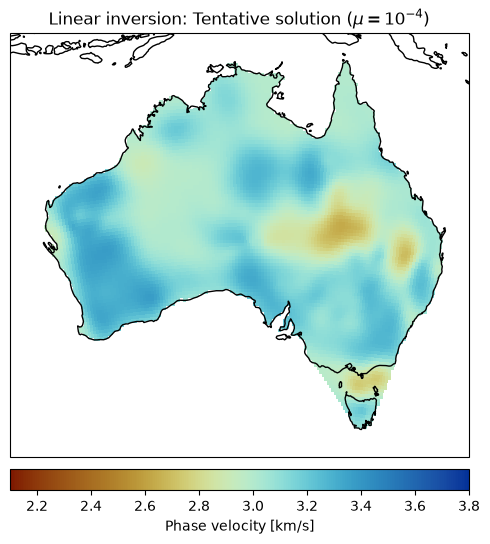

In [ ]:
# Plot tentative solution
fig_tentative = plot_map(c_tentative, title=r"Linear inversion: Tentative solution ($\mu=10^{-4}$)", vmin=cmin, vmax=cmax)
save_fig(fig_tentative, 'Linear_trial')
fig_tentative

In this case we guessed a value of the roughness-damping  trade-off parameter $\mu$ which looks to be too large, as it has favours model smoothness over data fitting.

### L-Curve Analysis

An **L-curve analysis** can be used to select a more meaningful value of $\mu$.

The L-curve plots the norm of the residual against the norm of the regularization term for different values of $\mu$. The optimal value is typically at the "corner" of the L-curve.

The `LCurve` utility class wraps CoFI's `InversionPool` to run multiple inversions efficiently. Next we calculate and plot the L-curve ad estimate an optimal value.

In [ ]:
"""L-Curve utility for regularization parameter selection."""

class LCurve:
    """L-curve analysis for selecting optimal regularization parameter.

    The L-curve plots residual norm against regularization norm on a log-log
    scale. The optimal regularization parameter is typically at the "corner".

    Parameters
    ----------
    reg_params : array-like
        Regularization parameters to test.
    problem_factory : callable
        Function that takes a regularization parameter and returns a
        configured cofi.BaseProblem.
    options_factory : callable
        Function that returns cofi.InversionOptions.
    forward_op : callable
        Function to compute predicted data: forward_op(model) -> d_pred.
    reg_norm_func : callable
        Function to compute regularization norm: reg_norm_func(model) -> float.
    d_obs : array-like
        Observed data vector.
    """

    def __init__(self, reg_params, problem_factory, options_factory, forward_op, reg_norm_func, d_obs):
        self.reg_params = np.asarray(reg_params)
        self.problem_factory = problem_factory
        self.options_factory = options_factory
        self.forward_op = forward_op
        self.reg_norm_func = reg_norm_func
        self.d_obs = d_obs

        # Results (populated after run())
        self.residual_norms = None
        self.reg_norms = None

    def run(self, parallel=False):
        """Run inversions for all regularization parameters."""
        problems = [self.problem_factory(mu) for mu in self.reg_params]

        reg_params = self.reg_params  # capture for closure

        def callback(inv_result, i):
            model = inv_result.model
            d_pred = self.forward_op(model)
            res_norm = np.linalg.norm(self.d_obs - d_pred)
            reg_norm = self.reg_norm_func(model)
            print(f"Finished inversion with mu={reg_params[i]:.2e}")
            print(f"    Res. Norm: {res_norm:.5f}, Reg. Norm {reg_norm:.5f}")
            return res_norm, reg_norm

        pool = cofi.utils.InversionPool(
            list_of_inv_problems=problems,
            list_of_inv_options=self.options_factory(),
            callback=callback,
            parallel=parallel
        )
        _, cb_returns = pool.run()

        # Unpack results
        l_curve_points = list(zip(*cb_returns))
        self.residual_norms, self.reg_norms = np.array(l_curve_points)
        self._corner_idx = None

        return self

    def find_corner(self):
        """Find the corner of the L-curve.

        Uses the point closest to the origin in normalised linear space
        (Pareto-optimal trade-off between residual and regularisation norms).
        The result should be verified visually using the labelled plot.

        Returns
        -------
        optimal_param : float
            The regularization parameter at the corner.
        corner_idx : int
            Index of the corner point.
        """
        if self.residual_norms is None:
            raise RuntimeError("Must call run() before find_corner()")

        x = (self.residual_norms - self.residual_norms.min()) / (self.residual_norms.max() - self.residual_norms.min())
        y = (self.reg_norms - self.reg_norms.min()) / (self.reg_norms.max() - self.reg_norms.min())
        self._corner_idx = int(np.argmin(x**2 + y**2))
        return self.reg_params[self._corner_idx], self._corner_idx

    @property
    def optimal_param(self):
        """Get optimal regularization parameter at the L-curve corner."""
        if self._corner_idx is None:
            self.find_corner()
        return self.reg_params[self._corner_idx]

    def plot(self, highlight_corner=True):
        """Plot the L-curve matching cofi-examples style.

        Parameters
        ----------
        highlight_corner : bool
            Whether to highlight the automatically detected corner point.
        """
        if self.residual_norms is None:
            raise RuntimeError("Must call run() before plot()")

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(self.residual_norms, self.reg_norms, 'k.-')
        ax.set_xlabel(r'Norm of residual $||Am-d||_2$')
        ax.set_ylabel(r'Norm of regularization term $||Rm||_2$')

        # Compute outward label offsets: away from the origin side of
        # the curve so labels don't overlap the line/dots.
        # Use the tangent direction to place labels on the outer side.
        res = self.residual_norms
        reg = self.reg_norms
        n_pts = len(res)
        for j, (mu, res_norm, reg_norm) in enumerate(zip(
                self.reg_params, res, reg)):
            ax.plot(res_norm, reg_norm, 'ro')
            # Tangent direction (in axes-fraction coords for consistency)
            ax_xlim = ax.get_xlim() or (res.min(), res.max())
            ax_ylim = ax.get_ylim() or (reg.min(), reg.max())
            xspan = ax_xlim[1] - ax_xlim[0] or 1
            yspan = ax_ylim[1] - ax_ylim[0] or 1
            if j == 0:
                tx = (res[1] - res[0]) / xspan
                ty = (reg[1] - reg[0]) / yspan
            elif j == n_pts - 1:
                tx = (res[-1] - res[-2]) / xspan
                ty = (reg[-1] - reg[-2]) / yspan
            else:
                tx = (res[j+1] - res[j-1]) / xspan
                ty = (reg[j+1] - reg[j-1]) / yspan
            # Outward normal (away from origin): rotate tangent +90°
            nx, ny = -ty, tx
            norm = np.sqrt(nx**2 + ny**2) or 1
            nx, ny = nx / norm, ny / norm
            # Offset in data coordinates
            offset_x = nx * xspan * 0.02
            offset_y = ny * yspan * 0.02
            # Alignment follows offset direction
            ha = 'left' if nx > 0.3 else ('right' if nx < -0.3 else 'center')
            va = 'bottom' if ny > 0.3 else ('top' if ny < -0.3 else 'center')
            ax.text(
                res_norm + offset_x,
                reg_norm + offset_y,
                s=r'$%s$' % scientific_label(mu, 1),
                va=va, ha=ha, fontsize=8, color='r',
            )

        if highlight_corner:
            if self._corner_idx is None:
                self.find_corner()
            idx = self._corner_idx
            ax.plot(
                self.residual_norms[idx], self.reg_norms[idx],
                'g*', markersize=20, markeredgecolor='black', markeredgewidth=1,
                label=r'Corner: $\mu=%s$' % scientific_label(self.optimal_param, 2)
            )
            ax.legend(loc='upper right')

        return fig

In [ ]:
_uses = inv_problem  # DAG ordering: L-curve runs after linear section

# Factory functions create fresh instances (L-curve needs independent objects per μ)
def _make_problem(mu):
    problem = BaseProblem()
    problem.set_data(r)  # residual for perturbation formulation
    problem.set_jacobian(A)
    problem.set_regularization(mu * regularization, mu * regularization.matrix)
    return problem

def _make_options():
    options = InversionOptions()
    options.set_tool("scipy.sparse.linalg")
    options.set_params(algorithm="minres")
    return options

# Create and run L-curve analysis
# forward_op computes predicted data from full model (m0 + perturbation)
# Use smaller μ range - regularization is strong relative to data misfit
lcurve = LCurve(
    reg_params=np.logspace(-7, -1, 20),
    problem_factory=_make_problem,
    options_factory=_make_options,
    forward_op=lambda dm: A @ (m0 + dm),  # dm is perturbation
    reg_norm_func=lambda dm: np.sqrt(regularization(dm)),
    d_obs=d_obs
)
lcurve.run()

Finished inversion with mu=1.00e-07
    Res. Norm: 0.00060, Reg. Norm 245.20660
Finished inversion with mu=2.07e-07
    Res. Norm: 0.00060, Reg. Norm 239.88725
Finished inversion with mu=4.28e-07
    Res. Norm: 0.00060, Reg. Norm 217.21608
Finished inversion with mu=8.86e-07
    Res. Norm: 0.00060, Reg. Norm 169.16742
Finished inversion with mu=1.83e-06
    Res. Norm: 0.00062, Reg. Norm 107.14886
Finished inversion with mu=3.79e-06
    Res. Norm: 0.00066, Reg. Norm 61.08141
Finished inversion with mu=7.85e-06
    Res. Norm: 0.00071, Reg. Norm 32.96334
Finished inversion with mu=1.62e-05
    Res. Norm: 0.00077, Reg. Norm 17.56294
Finished inversion with mu=3.36e-05
    Res. Norm: 0.00084, Reg. Norm 9.27495
Finished inversion with mu=6.95e-05
    Res. Norm: 0.00092, Reg. Norm 4.88559
Finished inversion with mu=1.44e-04
    Res. Norm: 0.00103, Reg. Norm 2.77568
Finished inversion with mu=2.98e-04
    Res. Norm: 0.00120, Reg. Norm 1.72893
Finished inversion with mu=6.16e-04
    Res. Norm: 

<__main__.LCurve object at 0xffff0664b4a0>

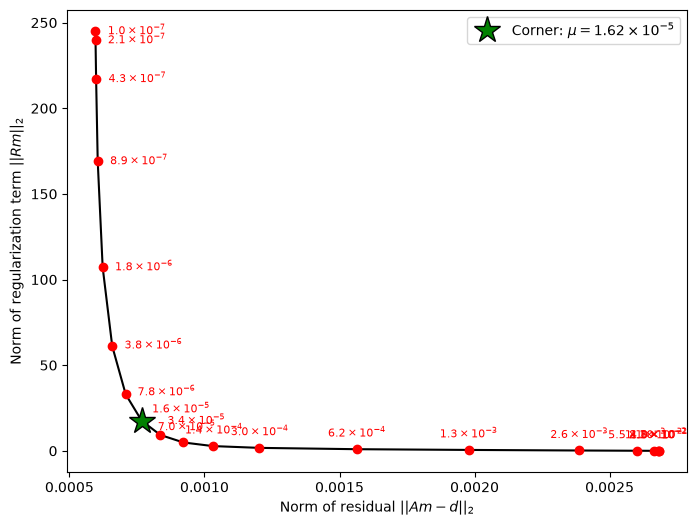

In [ ]:
# Plot L-curve
fig_lcurve = lcurve.plot()
save_fig(fig_lcurve, 'Linear_Lcurve')
fig_lcurve

### Least-Squares Solution with Optimal Damping Coefficient

The L-curve analysis automatically identifies the optimal damping coefficient at the corner using a *nearest to origin* selection strategy. This value is then used to compute the final phase-velocity map.

In [ ]:
# Get optimal damping from L-curve corner detection
mu_optimal = lcurve.optimal_param
print(f"Optimal damping coefficient from L-curve: μ = {mu_optimal:.4g}")

# Reconfigure inv_problem with optimal damping and run
inv_problem.set_regularization(mu_optimal * regularization, mu_optimal * regularization.matrix)
final_inv = Inversion(inv_problem, inv_options)
final_result = final_inv.run()
final_inv.summary()

# Full model = reference + perturbation
# Convert slowness (s/m) to phase velocity (km/s)
m_final = m0 + final_result.model  # s/m
c_final = 1e-3 / m_final  # m/s → km/s

print(f"\nFinal solution with μ = {mu_optimal:.4g}:")
print(f"  Phase velocity range: [{c_final.min():.2f}, {c_final.max():.2f}] km/s")
print(f"  Mean phase velocity: {c_final.mean():.2f} km/s")

Optimal damping coefficient from L-curve: μ = 1.624e-05
Summary for Inversion
Completed with the following result:

Summary for inversion result
SUCCESS
model: [-3.85179438e-18  2.79925785e-17 -2.12962529e-16 ...  1.31831136e-09
 -8.76485640e-10 -2.34885776e-10]
info: 0
---------------------------------------
With inversion solver defined as below:

Summary for inversion options
Solving method: None set
Use `suggest_solving_methods()` to check available solving methods.
Backend tool: `<class 'cofi.tools._scipy_sparse_lstsq.ScipySparseLstSq'>` - SciPy's sparse linear system solvers for solving linear problems
References: ['https://docs.scipy.org/doc/scipy/reference/sparse.linalg.html#solving-linear-problems']
Use `suggest_tools()` to check available backend tools.
Solver-specific parameters: 
algorithm = minres
Use `suggest_solver_params()` to check required/optional solver-specific parameters.
---------------------------------------
For inversion problem defined as below:

Summary for 

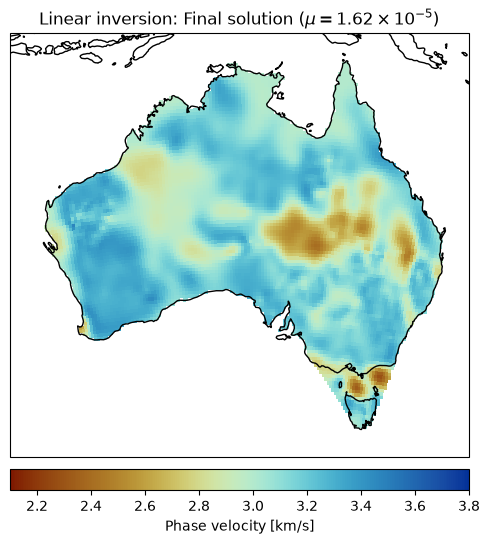

In [ ]:
# Plot final solution
fig_final = plot_map(c_final, title=r"Linear inversion: Final solution ($\mu=%s$)" % scientific_label(mu_optimal, 2),
                     vmin=cmin, vmax=cmax)
save_fig(fig_final, 'Linear_final')
fig_final

The above phase-velocity map aligns with that in Magrini et al. (2023), showing the expected velocity structure across Australia from 5s surface waves.

## Iterative Nonlinear Inversion

The linear inversion above assumes ray paths follow great circles, independent of the velocity model. This assumption breaks down when lateral velocity heterogeneities are strong enough to bend ray paths according to Fermat's principle.

### Why Nonlinear?

In the linear approach, the sensitivity matrix $\mathbf{A}$ is computed once using great circle paths. However, actual seismic waves follow minimum-time paths through the velocity structure. When velocity variations are significant:

1. **Ray paths bend** toward slow regions (higher slowness attracts rays)
2. **The Jacobian changes** as the velocity model updates
3. **The forward problem becomes nonlinear**: $\mathbf{d} = \mathbf{f}(\mathbf{m})$.

A researcher may decide that ray bending is significant for this dataset and so there is need to experiment with a nonlinear inversion approach.

In what follows the observed slowness values per path used in the linear case and converted to travel times by multiplication by the path distance.

### Gauss-Newton Iteration

This nonlinear problem is solved iteratively. At each iteration $k$:

1. **Trace rays** through the current model $\mathbf{m}_k$ to compute predicted travel times $\mathbf{f}(\mathbf{m}_k)$
2. **Compute the Fréchet derivative** $\mathbf{G}_k = \frac{\partial \mathbf{f}}{\partial \mathbf{m}}\big|_{\mathbf{m}_k}$
3. **Solve the linearised subproblem** $\Delta\mathbf{d}_k = \mathbf{G}_k \Delta\mathbf{m}_k$ for the model perturbation $\Delta\mathbf{m}_k$:
   where $\Delta\mathbf{d}_k = \mathbf{d} - \mathbf{f}(\mathbf{m}_k)$
4. **Update the model**: $\mathbf{m}_{k+1} = \mathbf{m}_k + \Delta\mathbf{m}_k$
5. **Repeat** until convergence (residual stops decreasing significantly)

This is the same formulation described in the introduction, now implemented with actual ray tracing.


A summary of relevant terms follows:

| Quantity | Units | Notes |
|----------|-------|-------|
| `d_obs` | s/m | Observed slowness from seislib |
| `distances` | m | Great circle inter-station distances |
| `d_obs_tt` | s | Observed travel times: $t = s \cdot d$ |
| Model `m` (pyfm2d) | s/km | Slowness at each grid node |
| Velocity (pyfm2d) | km/s | pyfm2d internally uses $v = 1/m$ |
| Fréchet matrix | s/(s/km) = km | Sensitivity of travel time to slowness |

The forward problem computes **travel times** by solving the eikonal equation:
$$t_i = \int_{\text{ray}_i} s(\mathbf{x}) \, dl$$

where the ray path itself depends on the slowness model $s(\mathbf{x})$, making this a nonlinear problem.

### pyfm2d Setup

**pyfm2d** (Python Fast Marching 2D) handles the nonlinear forward problem. pyfm2d implements the Fast Marching Method for 2D wavefront tracking, which:

- Computes travel times by solving the eikonal equation
- Provides Fréchet derivatives (sensitivity to slowness) in the same call
- Supports spherical coordinates for surface wave tomography (lat/lon)
- Is efficient enough for iterative inversion with ~15,000 rays

#### From slowness in rectangular cells to slowness at nodes

Since the 2D wavefront tracker internally represents a velocity model in terms of nodes on a regular grid, rather than values within cells, it makes sense to use the same representation as model parameters in the inversion. As a consequence for the nonlinear inversion the number of model parameters becomes 19456, but the problem is similar under, or more likely mixed-determined and requires regularization.

#### Parallelisation Strategy

Ray tracing is parallelised over sources using `ProcessPoolExecutor`. Each source is traced independently in a separate process, and results are combined after all sources complete. Process-based parallelism is required because pyfm2d's underlying C/Fortran code is not thread-safe. This pattern:

- Provides explicit control over worker allocation
- Enables progress reporting via `tqdm` (showing completed sources)
- Isolates each worker in its own memory space (avoids thread-safety issues)
- Scales well to the number of available CPU cores

In [ ]:
import pyfm2d

In [ ]:
# Grid extent for pyfm2d [lonmin, lonmax, latmin, latmax]
# Matches the seislib grid exactly — all stations are at least 2.7° inside
# these bounds, so no additional buffer is needed for pyfm2d.
fm2d_extent = [lonmin, lonmax, latmin, latmax]

# Compute grid shape from extent and resolution
# pyfm2d expects velocity as (nx, ny) = (n_lon, n_lat)
n_lon = int(np.round((fm2d_extent[1] - fm2d_extent[0]) / grid_resolution)) + 1
n_lat = int(np.round((fm2d_extent[3] - fm2d_extent[2]) / grid_resolution)) + 1
fm2d_grid_shape = (n_lon, n_lat)

# Note: the source-receiver associations below cover the same geometry as the
# linear inversion, but seislib handles that internally (inside compile_coefficients)
# and does not expose it in a form pyfm2d can use. pyfm2d requires an explicit
# associations matrix, local index mappings, and a reorder array, so the
# geometry must be reconstructed here from the same raw station_pairs data.

# Get unique sources and receivers from (possibly subsetted) station_pairs
unique_src_idx = np.unique(station_pairs[:, 0])
unique_rec_idx = np.unique(station_pairs[:, 1])

# Create index mappings
src_map = {sta_idx: local_idx for local_idx, sta_idx in enumerate(unique_src_idx)}
rec_map = {sta_idx: local_idx for local_idx, sta_idx in enumerate(unique_rec_idx)}

# Build associations matrix
n_src = len(unique_src_idx)
n_rec = len(unique_rec_idx)
fm2d_associations = np.zeros((n_rec, n_src), dtype=np.int32)
for src_idx, rec_idx in station_pairs:
    fm2d_associations[rec_map[rec_idx], src_map[src_idx]] = 1

# Sources and receivers in [lon, lat] format for pyfm2d
fm2d_sources = stations[unique_src_idx][:, ::-1]
fm2d_receivers = stations[unique_rec_idx][:, ::-1]

# Build mapping from pyfm2d output order to station_pairs order
# pyfm2d with multithreading outputs: for each source, receivers with associations==1
# Map this back to station_pairs order
pyfm2d_to_pairs = {}  # (src_local, rec_local) -> index in station_pairs
for pair_idx, (src_idx, rec_idx) in enumerate(station_pairs):
    src_local = src_map[src_idx]
    rec_local = rec_map[rec_idx]
    pyfm2d_to_pairs[(src_local, rec_local)] = pair_idx

# Build reorder indices: pyfm2d output order -> station_pairs order
# pyfm2d outputs in source-major order: for each source, list receivers
fm2d_reorder = []
for src_local in range(n_src):
    for rec_local in range(n_rec):
        if fm2d_associations[rec_local, src_local] == 1:
            fm2d_reorder.append(pyfm2d_to_pairs[(src_local, rec_local)])
fm2d_reorder = np.array(fm2d_reorder)

print(f"pyfm2d configuration:")
print(f"  Grid shape: {fm2d_grid_shape} ({n_lat} lat x {n_lon} lon = {n_lat * n_lon:,} cells)")
print(f"  Sources: {n_src}, Receivers: {n_rec}, Pairs: {len(station_pairs):,}")

pyfm2d configuration:
  Grid shape: (152, 128) (128 lat x 152 lon = 19,456 cells)
  Sources: 1074, Receivers: 1042, Pairs: 13,299


In [ ]:
# Write worker module for parallel pyfm2d execution.
# ProcessPoolExecutor requires functions to be importable from a module,
# so this file is generated in a scratch directory.
import sys as _sys
from pathlib import Path
from textwrap import dedent

_worker_code = dedent("""
    \"\"\"Worker function for parallel pyfm2d ray tracing.

    This module is auto-generated by the notebook because ProcessPoolExecutor
    requires picklable functions defined at module level.
    \"\"\"

    import numpy as np


    def compute_single_source(args):
        \"\"\"Compute travel times for a single source using pyfm2d.

        Parameters
        ----------
        args : tuple
            (src_idx, velocity, receivers, source, extent, return_jacobian)

        Returns
        -------
        tuple
            (src_idx, ttimes, frechet_data) where frechet_data is tuple for pickling
        \"\"\"
        src_idx, velocity, receivers, source, extent, return_jacobian = args

        import pyfm2d
        from pyfm2d import WaveTrackerOptions

        options = WaveTrackerOptions(
            times=True,
            frechet=return_jacobian,
            paths=return_jacobian,
            cartesian=False,
            quiet=True,
        )

        result = pyfm2d.calc_wavefronts(
            velocity,
            receivers,
            source,
            extent=extent,
            options=options,
            nthreads=1,
        )

        if return_jacobian:
            frechet = result.frechet.tocsr()
            frechet_data = (frechet.data.copy(), frechet.indices.copy(),
                            frechet.indptr.copy(), frechet.shape)
            return src_idx, result.ttimes.copy(), frechet_data
        return src_idx, result.ttimes.copy(), None
""").lstrip()

# Create temp directory and write worker module there
import tempfile

scratch_dir = Path(tempfile.mkdtemp(prefix="cofi_beans_"))
pyfm2d_worker_path = scratch_dir / "pyfm2d_worker.py"
pyfm2d_worker_path.write_text(_worker_code)

# Add temp directory to sys.path for import
scratch_str = str(scratch_dir)
if scratch_str not in _sys.path:
    _sys.path.insert(0, scratch_str)

pyfm2d_worker_ready = True

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
from pyfm2d_worker import compute_single_source
_uses = pyfm2d_worker_ready  # Ensure worker file is written first
import os

# Determine number of parallel workers (use all available CPUs)
n_workers = os.cpu_count() or 1

def forward_pyfm2d(slowness_model, return_jacobian=False, progress=True):
    """Compute travel times (and optionally Jacobian) using pyfm2d.

    Uses ProcessPoolExecutor for parallel execution over sources with progress reporting.
    Process-based parallelism is required because pyfm2d's C/Fortran code is not thread-safe.
    Workers are set to os.cpu_count() so the pool uses all available cores.

    Parameters
    ----------
    slowness_model : array-like
        Slowness model as a 1D array (n_cells,) in s/km.
    return_jacobian : bool
        If True, return (travel_times, jacobian).
    progress : bool
        If True, show progress bar.

    Returns
    -------
    travel_times : ndarray
        Predicted travel times for each source-receiver pair, in station_pairs order.
    jacobian : sparse matrix (optional)
        Frechet derivative matrix (n_obs, n_cells).
    """
    # Convert slowness (s/km) to velocity (km/s) and reshape to grid
    velocity = 1.0 / slowness_model.reshape(fm2d_grid_shape)
    n_sources = fm2d_sources.shape[0]

    # Parallel execution over sources with progress bar
    # Using ProcessPoolExecutor because pyfm2d C/Fortran code is not thread-safe
    all_ttimes = {}
    all_frechet = {} if return_jacobian else None

    # Build task arguments as tuples for the worker function
    tasks = []
    for src_idx in range(n_sources):
        rec_mask = fm2d_associations[:, src_idx] == 1
        if not np.any(rec_mask):
            continue
        source = fm2d_sources[src_idx:src_idx+1]
        receivers = fm2d_receivers[rec_mask]
        tasks.append((src_idx, velocity, receivers, source, fm2d_extent, return_jacobian))

    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        # Submit all tasks
        futures = {executor.submit(compute_single_source, task): task[0] for task in tasks}

        iterator = as_completed(futures)
        if progress:
            iterator = tqdm(iterator, total=len(futures), desc="Ray tracing", unit="src")

        for future in iterator:
            src_idx, ttimes, frechet_data = future.result()
            if ttimes is not None:
                all_ttimes[src_idx] = ttimes
                if return_jacobian and frechet_data is not None:
                    all_frechet[src_idx] = frechet_data

    # Combine results in source order and reorder to station_pairs order
    ttimes_list = []
    frechet_list = [] if return_jacobian else None

    for src_idx in range(n_sources):
        if src_idx in all_ttimes:
            ttimes_list.append(all_ttimes[src_idx])
            if return_jacobian:
                # Reconstruct sparse matrix from tuple (data, indices, indptr, shape)
                data, indices, indptr, shape = all_frechet[src_idx]
                frechet_mat = scipy.sparse.csr_matrix((data, indices, indptr), shape=shape)
                frechet_list.append(frechet_mat)

    ttimes_combined = np.concatenate(ttimes_list)
    ttimes_out = np.empty(len(fm2d_reorder))
    ttimes_out[fm2d_reorder] = ttimes_combined

    if return_jacobian:
        frechet_combined = scipy.sparse.vstack(frechet_list)
        frechet_out = frechet_combined.tocsr()[np.argsort(fm2d_reorder), :]
        return ttimes_out, frechet_out
    return ttimes_out

In [ ]:
# Convert observed slowness to travel times using great circle distances
# d_obs is slowness in s/m; convert to travel times in seconds
R_earth = 6371000.0

def haversine_distance(lat1, lon1, lat2, lon2):
    """Compute great circle distance in meters."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R_earth * np.arcsin(np.sqrt(a))

distances = np.array([
    haversine_distance(
        stations[s1, 0], stations[s1, 1],
        stations[s2, 0], stations[s2, 1]
    )
    for s1, s2 in station_pairs
])

d_obs_tt = d_obs * distances
print(f"Observed travel times computed from real data:")
print(f"  Distance range: [{distances.min()/1000:.1f}, {distances.max()/1000:.1f}] km")
print(f"  Travel time range: [{d_obs_tt.min():.1f}, {d_obs_tt.max():.1f}] s")

Observed travel times computed from real data:
  Distance range: [20.5, 1999.9] km
  Travel time range: [7.5, 635.4] s


### Regularisation for the Nonlinear Inversion

Two regularization operators are available, selectable via `use_gaussian_reg` in the cell below.

**Option 1 — Second-order Laplacian** (`use_gaussian_reg = False`)

A rectangular finite-difference operator that penalises curvature (second spatial
derivatives) of the slowness field:

$$\mathbf{R} = \begin{bmatrix} \mathbf{I} \otimes \mathbf{D}_2^{\text{lat}} \\ \mathbf{D}_2^{\text{lon}} \otimes \mathbf{I} \end{bmatrix}, \quad \mathbf{D}_2 = \begin{bmatrix}1 & -2 & 1 \\ & \ddots \end{bmatrix}$$

This is the same operator type as seislib's `roughness_operator`, adapted for the
pyfm2d node-based grid. It is scale-free: the single free parameter is $\mu$,
which controls the trade-off between data fit and model roughness.

**Option 2 — SPDE Matérn ν=1** (`use_gaussian_reg = True`)

A sparse square precision-factor operator derived from the stochastic partial
differential equation (SPDE) link to Gaussian random fields (Lindgren et al. 2011).
For Matérn smoothness ν=1 in 2D, the precision matrix is $\mathbf{Q} = \mathbf{R}^T\mathbf{R}$ where:

$$\mathbf{R} = \tau \mathbf{M}^{1/2}(\kappa^2 \mathbf{I} - \mathbf{L}_h), \quad \kappa = \sqrt{2}/\ell, \quad \tau = \frac{1}{2\sqrt{\pi}\,\kappa\,\sigma}$$

Here $\mathbf{L}_h$ is the grid-spacing-aware 2D discrete Laplacian and
$\mathbf{M}$ is the lumped mass matrix. On a uniform grid, $\mathbf{M} \approx h_x h_y \mathbf{I}$,
so the implemented factor is $\mathbf{R} = \tau \sqrt{h_x h_y}(\kappa^2 \mathbf{I} - \mathbf{L}_h)$.
Regularisation is applied to $\mathbf{m} - \mathbf{m}_0$ so the penalty is zero
for the background model.

#### Matérn ν=1 correlation function

The standard Matérn kernel with length scale $\ell$ and smoothness $\nu = 1$ gives the
spatial correlation between two nodes separated by distance $r$ as:

$$C(r) = \frac{\sqrt{2}\,r}{\ell} \, K_1\!\left(\frac{\sqrt{2}\,r}{\ell}\right)$$

where $K_1$ is the modified Bessel function of the second kind of order 1. This function
has the properties:

| Distance | Correlation |
|----------|-------------|
| $r = 0$ | $C = 1$ |
| $r = \ell$ | $C \approx 0.44$ |
| $r = 2\ell$ (practical range $\rho$) | $C \approx 0.14$ |
| $r = 3\ell$ | $C \approx 0.04$ |

The practical range $\rho = 2\ell$ is the distance at which correlation drops to ~0.14.
Larger $\ell$ forces smoother models.

$\sigma$ is the **marginal standard deviation** of the slowness perturbation field —
i.e. the prior standard deviation at any single grid node. Setting $\sigma = 0.02$ s/km
encodes a belief that slowness deviates from the background by at most ~$2\sigma \approx \pm 0.04$ s/km,
corresponding to roughly $\pm$12% velocity variation about 3 km/s.
The plot below shows $C(r)$ for the current value of $\ell$.

In [ ]:
# Toggle between regularization types for the nonlinear (pyfm2d) inversion:
#   False → second-order Laplacian (rectangular, same type as seislib's roughness_operator)
#   True  → SPDE Matérn ν=1: R = tau * (κ²I − L_h), κ = sqrt(2) / ell
use_gaussian_reg = True
ell = np.sqrt(2)*5*grid_resolution#2.12       # Matérn length scale in degrees (practical range rho = 2*ell ≈ 4.24°)
sigma = 5*0.02*(1/(2*np.sqrt(np.pi)))    # Prior std dev of slowness perturbations in s/km (~±6% at 3 km/s)

In [ ]:
_fig = None
if use_gaussian_reg:
    from scipy.special import kv as _kv
    _kappa = np.sqrt(2.0) / ell
    _rho = 2.0 * ell
    _r_deg = np.linspace(1e-6, 2.0 * _rho, 400)
    _x = _kappa * _r_deg
    _corr = _x * _kv(1, _x)
    _r_km = _r_deg * 111.0
    _ell_km = ell * 111.0
    _rho_km = _rho * 111.0

    _fig, _ax = plt.subplots(figsize=(5, 2.8))
    _ax.plot(_r_km, _corr, 'k-', lw=1.5)
    _ax.axvline(_ell_km, color='C1', ls='--', lw=1,
                label=f'$\\ell$ = {ell:.2f}° ≈ {_ell_km:.0f} km  (corr ≈ 0.44)')
    _ax.axvline(_rho_km, color='C0', ls='--', lw=1,
                label=f'$\\rho = 2\\ell$ = {_rho:.2f}° ≈ {_rho_km:.0f} km  (corr ≈ 0.14)')
    _ax.axhline(0.14, color='C0', ls=':', lw=0.8, alpha=0.6)
    _ax.set_xlabel('Distance $r$ (km)')
    _ax.set_ylabel('Correlation $C(r)$')
    _ax.set_title('Matérn ν=1 correlation function')
    _ax.legend(fontsize=9)
    _ax.set_ylim(-0.02, 1.05)
    _ax.set_xlim(0, None)
    _fig.tight_layout()
    save_fig(_fig, 'correlation_comparison')
    _fig

The SPDE branch uses `cofi.utils.SPDEMaternReg` to build the Matérn ν=1 precision factor **R = τ(κ²I − L_h)** with **Neumann (zero-flux) boundary conditions**, where κ = √2/ℓ and τ = 1/(2√π κ σ). The practical range is ρ = 2ℓ. The grid-spacing-aware Laplacian L_h correctly accounts for the physical cell size. The Laplacian branch uses `cofi.utils.QuadraticReg` with a manually-built rectangular second-order operator, matching seislib's roughness operator type.

In [ ]:
# Starting model: uniform 3 km/s (slowness in s/km for pyfm2d)
_n_params = fm2d_grid_shape[0] * fm2d_grid_shape[1]
m0_pyfm2d = np.full(_n_params, 1.0 / 3.0)  # 3 km/s -> 1/3 s/km

In [ ]:
# Seislib uses a cell-centred grid (19,328 cells) while pyfm2d uses grid
# nodes. Hence the model grid for the linear case differs slightly from that
# for the nonlinear cases and so we need to build new regularization operators.

_n_lon, _n_lat = fm2d_grid_shape
_n_params = _n_lon * _n_lat

if use_gaussian_reg:
    # SPDE Matérn ν=1 via cofi.utils. Uses Neumann (zero-flux) BCs, which
    # avoids spurious boundary anchoring present in plain tridiagonal truncation.
    regularization_pyfm2d = cofi.utils.SPDEMaternReg(
        model_shape=fm2d_grid_shape,
        ell=ell,
        sigma=sigma,
        grid_spacing=grid_resolution,
        reference_model=m0_pyfm2d,
    )
    _ell_km = ell * 111.0
    reg_label = (
        "SPDE Matérn ν=1 via cofi.utils "
        f"(ℓ={ell:.2f}° ≈ {_ell_km:.0f} km, ρ=2ℓ≈{2*ell:.2f}°, σ={sigma} s/km)"
    )
else:
    # Second-order (Laplacian) finite differences — rectangular operator,
    # same type as seislib's roughness_operator.
    _D2_lat = scipy.sparse.diags([1, -2, 1], [0, 1, 2], shape=(_n_lat - 2, _n_lat))
    _D2_lon = scipy.sparse.diags([1, -2, 1], [0, 1, 2], shape=(_n_lon - 2, _n_lon))
    _R = scipy.sparse.vstack([
        scipy.sparse.kron(scipy.sparse.eye(_n_lon), _D2_lat),
        scipy.sparse.kron(_D2_lon, scipy.sparse.eye(_n_lat)),
    ])
    regularization_pyfm2d = cofi.utils.QuadraticReg(_R, (_n_params,))
    reg_label = "second-order Laplacian (rectangular)"

R_pyfm2d = regularization_pyfm2d.matrix
print(f"Nonlinear regularization ({reg_label}):")
print(f"  Grid: {_n_lon} lon × {_n_lat} lat = {_n_params:,} cells")
print(f"  R shape: {R_pyfm2d.shape} (weighting matrix W, used as W @ m in penalty)")

Nonlinear regularization (SPDE Matérn ν=1 via cofi.utils (ℓ=2.12° ≈ 235 km, ρ=2ℓ≈4.24°, σ=0.028209479177387815 s/km)):
  Grid: 152 lon × 128 lat = 19,456 cells
  R shape: (19456, 19456) (weighting matrix W, used as W @ m in penalty)


#### L-BFGS-B algorithm

Our first attempt at iterative nonlinear minimization uses the Limited-memory Broyden–Fletcher–Goldfarb–Shanno (L-BFGS-B) algortihm. CoFI supports `scipy.optimize.minimize` for nonlinear problems, which works with a general scalar objective function:

$$\phi(\mathbf{m}) = \frac{1}{2}\|\mathbf{d} - \mathbf{f}(\mathbf{m})\|^2 + \frac{\mu}{2}\|\mathbf{R}(\mathbf{m}-\mathbf{m}_0)\|^2$$

The gradient is computed as:

$$\nabla\phi = -\mathbf{G}^\top(\mathbf{d} - \mathbf{f}(\mathbf{m})) + \mu\mathbf{R}^\top\mathbf{R}(\mathbf{m}-\mathbf{m}_0)$$

This approach is useful when you want to use optimisation algorithms like L-BFGS-B, which can be more efficient for problems with many parameters.

In [ ]:
# Reconfigure inv_problem for objective + gradient formulation
# c_final ensures DAG ordering: minimize runs after linear stage
_uses = c_final

# Local mu defaults for L-BFGS-B (same calibrated values as the L-curve cell).
# The L-curve runs after this block, so mu_minimize is set independently here.
if use_gaussian_reg:
    mu_minimize = 2.37e-2 if run_mode == "fast" else 2.0
else:
    mu_minimize = 10.0

# Data
inv_problem.set_data(d_obs_tt)

# Initial model
inv_problem.set_initial_model(m0_pyfm2d)

# Clear bounds from previous stage — CoFI's format is incompatible with scipy.optimize.minimize
inv_problem._bounds = None

# Progress tracking state
class MinimizeProgress:
    def __init__(self):
        self.nfev = 0
        self.njev = 0
        self.iteration = 0
        self.prev_cost = None
        self.header_printed = False

    def print_header(self):
        if not self.header_printed:
            print(f"   {'Iteration':>9}     {'Total nfev':>10}        {'Cost':>12}      {'Cost reduction':>14}    {'Optimality':>10}")
            self.header_printed = True

progress = MinimizeProgress()

# Objective function: 0.5 * ||d - f(m)||^2 + 0.5 * mu * ||R @ (m-m0)||^2
def objective(m):
    progress.nfev += 1
    d_pred = forward_pyfm2d(m, progress=False)
    residual = d_obs_tt - d_pred
    data_misfit = 0.5 * np.dot(residual, residual)
    Rm = R_pyfm2d @ (m - m0_pyfm2d)
    reg_term = 0.5 * mu_minimize * np.dot(Rm, Rm)
    return data_misfit + reg_term

inv_problem.set_objective(objective)

# Gradient: -G.T @ (d - f(m)) + mu * R.T @ R @ (m - m0)
def gradient(m):
    progress.njev += 1
    d_pred, G = forward_pyfm2d(m, return_jacobian=True, progress=True)
    residual = d_obs_tt - d_pred
    data_grad = -G.T @ residual  # G is sparse, use matrix multiply
    reg_grad = mu_minimize * (R_pyfm2d.T @ (R_pyfm2d @ (m - m0_pyfm2d)))
    return np.asarray(data_grad).flatten() + reg_grad

inv_problem.set_gradient(gradient)

# Callback to print iteration progress
def iteration_callback(xk):
    progress.print_header()
    cost = objective(xk)
    grad = gradient(xk)
    grad_norm = np.linalg.norm(grad)

    if progress.prev_cost is not None:
        cost_reduction = progress.prev_cost - cost
        print(f"   {progress.iteration:>9}     {progress.nfev:>10}         {cost:.4e}      {cost_reduction:>+.2e}       {grad_norm:.2e}")
    else:
        print(f"   {progress.iteration:>9}     {progress.nfev:>10}         {cost:.4e}                           {grad_norm:.2e}")

    progress.prev_cost = cost
    progress.iteration += 1

# Reconfigure inv_options for scipy.optimize.minimize (L-BFGS-B)
inv_options.set_tool("scipy.optimize.minimize")
inv_options.hyper_params.clear()
inv_options.set_params(
    method="L-BFGS-B",  # Limited-memory BFGS with box constraints
    callback=iteration_callback,
    options={
        "maxiter": 10,
        "disp": False,   # progress display handled via callback
        "ftol": 1e-6,    # tolerance on cost function change
        "gtol": 1e-5,    # tolerance on gradient
    }
)

print(f"Running CoFI with scipy.optimize.minimize (L-BFGS-B, mu={mu_minimize:.0e})...")
print("-" * 60)
minimize_inv = Inversion(inv_problem, inv_options)
minimize_result = minimize_inv.run()
print("-" * 60)

# Convert result to velocity
m_minimize = minimize_result.model
c_minimize = 1.0 / m_minimize
print(f"\nscipy.optimize.minimize result:")
print(f"  Velocity range: [{c_minimize.min():.2f}, {c_minimize.max():.2f}] km/s")

# Compute final residual for comparison
d_pred_minimize = forward_pyfm2d(m_minimize, progress=False)
residual_minimize = np.linalg.norm(d_obs_tt - d_pred_minimize)
print(f"  Final residual norm: {residual_minimize:.2f}")

Running CoFI with scipy.optimize.minimize (L-BFGS-B, mu=2e+00)...
------------------------------------------------------------


Ray tracing: 100%|██████████| 1074/1074 [01:17<00:00, 13.85src/s]


   Iteration     Total nfev                Cost      Cost reduction    Optimality


Ray tracing: 100%|██████████| 1074/1074 [01:15<00:00, 14.22src/s]


           0              4         2.8132e+05                           6.65e+05


...

           7             18         3.3964e+04      +8.06e+03       5.85e+04


Ray tracing: 100%|██████████| 1074/1074 [01:20<00:00, 13.38src/s]


           8             20         2.8633e+04      +5.33e+03       7.93e+04


Ray tracing: 100%|██████████| 1074/1074 [01:19<00:00, 13.53src/s]


           9             22         2.4978e+04      +3.66e+03       4.53e+04
------------------------------------------------------------

scipy.optimize.minimize result:
  Velocity range: [2.42, 3.60] km/s
  Final residual norm: 209.53


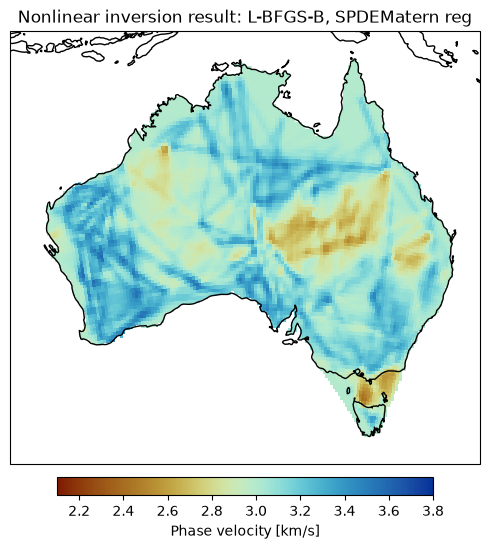

In [ ]:
if(use_gaussian_reg):
    ptitle = 'Nonlinear inversion result: L-BFGS-B, SPDEMatern reg'
else:
    ptitle = 'Nonlinear inversion result: L-BFGS-B, 2nd order Laplace reg'
fig_minimize = plot_map(c_minimize, title=ptitle,
                        grid_shape=fm2d_grid_shape, extent=fm2d_extent, vmin=cmin, vmax=cmax)
save_fig(fig_minimize, 'Nonlinear_LBFGSB')
fig_minimize

**Ray-streak artefacts:** In practice, the L-BFGS-B result tends to show streaky structure aligned with ray paths, particularly with limited data. This occurs because the gradient $\nabla\phi$ projects sensitivity back along rays, so model updates are concentrated where rays pass. In this case regularisation enters only as a scalar gradient term that L-BFGS-B's limited-memory Hessian approximation does not capture well — especially in limited numbers of iterations.

Next we attempt CoFI's `least_squares` solver applied to an augmented linear system of equations.

### Improved: An iterative least squares solver on an augmented system

#### Regularisation via Augmented System

Since `scipy.optimize.least_squares` minimises $\|\mathbf{r}(\mathbf{m})\|^2$, regularisation may be incorporated by augmenting the residual vector:

$$\mathbf{r}_{\text{aug}}(\mathbf{m}) = \begin{bmatrix} \mathbf{d} - \mathbf{f}(\mathbf{m}) \\ \sqrt{\mu}\mathbf{R}(\mathbf{m} - \mathbf{m}_0) \end{bmatrix}$$

This ensures $\|\mathbf{r}_{\text{aug}}\|^2 = \|\mathbf{d} - \mathbf{f}(\mathbf{m})\|^2 + \mu\|\mathbf{R}(\mathbf{m}-\mathbf{m}_0)\|^2$. Subtracting $\mathbf{m}_0$ means the penalty is on perturbations from the background model — essential for the SPDE operator (whose $\kappa^2\mathbf{I}$ term is non-zero for a constant field) and harmless for the Laplacian (which annihilates any constant). The Jacobian is augmented correspondingly:

$$\mathbf{G}_{\text{aug}} = \begin{bmatrix} \mathbf{G} \\ \sqrt{\mu}\mathbf{R} \end{bmatrix}$$

where $\mathbf{G} = \frac{\partial \mathbf{f}}{\partial \mathbf{m}}$ is the Fréchet derivative from ray tracing. The Jacobian $\mathbf{G}$ from pyfm2d is sparse — each ray passes through only a small fraction of grid cells — so the augmented system is kept in sparse format throughout to avoid densification.

Next we set up this augmented linear system re-using previously defined elements.

In [ ]:
# Reconfigure inv_problem for nonlinear residual formulation
# c_minimize ensures DAG ordering: least_squares runs after minimize stage
_uses = c_minimize

# Data - augmented with regularisation term
# For least_squares, ||residuals||^2 is minimised, so the data vector is augmented
# with zeros for the regularisation term: [d_obs; 0]
n_reg = R_pyfm2d.shape[0]
d_augmented = np.concatenate([d_obs_tt, np.zeros(n_reg)])
inv_problem.set_data(d_augmented)

# Initial model
inv_problem.set_initial_model(m0_pyfm2d)

# Bounds to keep model physical (slowness s/km -> velocity km/s)
# Velocity range: 1.5 - 10 km/s -> Slowness range: 0.1 - 0.67 s/km
_n_params = len(m0_pyfm2d)
lower_bounds = np.full(_n_params, 1.0 / 10.0)  # 10 km/s max velocity
upper_bounds = np.full(_n_params, 1.0 / 1.5)   # 1.5 km/s min velocity
inv_problem.set_bounds((lower_bounds, upper_bounds))

# Reconfigure inv_options for scipy.optimize.least_squares
inv_options.set_tool("scipy.optimize.least_squares")
inv_options.hyper_params.clear()
# x_scale controls trust region size relative to parameters
# Setting x_scale = m0 means trust region of 1 corresponds to 100% change
# Using a fraction of m0 limits step to that fraction per iteration
step_fraction = 0.1  # limit step to ~10% of parameter value per iteration
x_scale = step_fraction * m0_pyfm2d

inv_options.set_params(
    method="trf",  # trust-region-reflective (handles bounds, robust)
    max_nfev=10,
    verbose=2,     # show progress
    x_scale=x_scale,  # fixed scale to limit Newton step size
    ftol=1e-4,     # tolerance on cost function change
    xtol=1e-4,     # tolerance on model change
    tr_solver="lsmr",  # iterative solver for trust region subproblem (better for large problems)
)

#### Optional Nonlinear L-curve

The next cell optionally calculates an optimal trade-off parameter $\mu$ via an L-curve calculation for the nonlinear inversion case. This can be very expensive when many raypaths are calculated, so by default we skip it and use a previously calculated value of $\mu$. To perform nonlinear L-curve, set the toggle below to on.

In [ ]:
nonlin_lcurve_switch = mo.ui.switch(
    value=False,
    label="Run nonlinear L-curve (fast mode only — expensive)"
)
mo.md(f"**Nonlinear regularisation parameter:** {nonlin_lcurve_switch}")

**Nonlinear regularisation parameter:** <marimo-ui-element object-id='IpqN-0' random-id='580c0b30-7e12-6c1e-96ce-80d0f07e7515'><marimo-switch data-initial-value='false' data-label='&quot;&#92;u003cspan class=&#92;&quot;markdown prose dark:prose-invert contents&#92;&quot;&#92;u003e&#92;u003cspan class=&#92;&quot;paragraph&#92;&quot;&#92;u003eRun nonlinear L-curve (fast mode only — expensive)&#92;u003c/span&#92;u003e&#92;u003c/span&#92;u003e&quot;' data-disabled='false'></marimo-switch></marimo-ui-element>

In [ ]:
# n_reg ensures DAG ordering: L-curve runs after augmented system setup
_uses = (c_minimize, n_reg)
if not nonlin_lcurve_switch.value:
    if use_gaussian_reg:
        if run_mode == "fast":
            mu_nonlin = 2.37e-2  # L-curve calibrated, 1% rays
        else:
            mu_nonlin = 2.0      # Visually calibrated, 100% rays
    else:
        if run_mode == "fast":
            mu_nonlin = 10.0     # L-curve calibrated, 1% rays
        else:
            mu_nonlin = 10.0     # Not yet calibrated for 100% rays — re-run L-curve
else:
    # Run L-curve sequentially — parallel=False required because forward_pyfm2d
    # itself uses ProcessPoolExecutor (no nested process pools).
    # The L-curve uses scipy.optimize.least_squares (the augmented-system solver),
    # so the optimal mu is formally calibrated for that algorithm. The L-BFGS-B
    # block runs before this L-curve and uses its own hardcoded defaults.
    #
    # The mu sweep range differs between regularizers: for the SPDE operator the
    # effective penalty is ~10,000× larger per unit mu than the Laplacian, so the
    # optimal mu shifts roughly 4 decades lower.
    if use_gaussian_reg:
        _mu_values = np.logspace(-6, -1, 9)
    else:
        _mu_values = np.logspace(-3, 1, 9)
    _n_reg = R_pyfm2d.shape[0]
    _res_norms = []
    _reg_norms = []

    print("Nonlinear L-curve sweep:")
    for _mu in _mu_values:
        _sqrt_mu = np.sqrt(_mu)
        _prob = cofi.BaseProblem()
        _prob.set_data(np.concatenate([d_obs_tt, np.zeros(_n_reg)]))
        _prob.set_initial_model(m0_pyfm2d)

        def _fwd(m, _s=_sqrt_mu, _m0=m0_pyfm2d):
            return np.concatenate([forward_pyfm2d(m, progress=False), _s * (R_pyfm2d @ (m - _m0))])

        def _jac(m, _s=_sqrt_mu):
            _, G = forward_pyfm2d(m, return_jacobian=True, progress=False)
            return scipy.sparse.vstack([G, _s * R_pyfm2d])

        _prob.set_forward(_fwd)
        _prob.set_jacobian(_jac)

        _opts = cofi.InversionOptions()
        _opts.set_tool("scipy.optimize.least_squares")
        _opts.set_params(method="trf", max_nfev=5, verbose=0, tr_solver="lsmr")

        _m = cofi.Inversion(_prob, _opts).run().model
        _res_norms.append(np.linalg.norm(d_obs_tt - forward_pyfm2d(_m, progress=False)))
        _reg_norms.append(np.linalg.norm(R_pyfm2d @ (_m - m0_pyfm2d)))
        print(f"  mu={_mu:.2e}: res={_res_norms[-1]:.4f}, reg={_reg_norms[-1]:.4f}")

    # Pareto-optimal corner (same criterion as linear L-curve)
    _res = np.array(_res_norms)
    _reg = np.array(_reg_norms)
    _res_n = (_res - _res.min()) / (_res.max() - _res.min())
    _reg_n = (_reg - _reg.min()) / (_reg.max() - _reg.min())
    _corner = np.argmin(np.sqrt(_res_n**2 + _reg_n**2))
    mu_nonlin = float(_mu_values[_corner])
    print(f"\nOptimal mu_nonlin = {mu_nonlin:.2e}")

print(f"mu_nonlin = {mu_nonlin}")

mu_nonlin = 2.0


In [ ]:
# Forward function with augmented regularisation
# Returns [forward(m); sqrt(mu) * R @ (m-m0)] so that ||residuals||^2 includes regularisation.
# Subtracting m0 ensures the penalty is on perturbations from the background model,
# which is required for the SPDE operator (R @ m0 ≠ 0 due to the κ²I term) and
# harmless for the Laplacian operator (R_Lap @ m0 = 0 for constant m0 anyway).
sqrt_mu = np.sqrt(mu_nonlin)
def forward_augmented(m):
    d_pred = forward_pyfm2d(m, progress=True)
    reg_term = sqrt_mu * (R_pyfm2d @ (m - m0_pyfm2d))
    return np.concatenate([d_pred, reg_term])

inv_problem.set_forward(forward_augmented)

# Jacobian function - also augmented (keep sparse!)
def jacobian_augmented(m):
    _, G = forward_pyfm2d(m, return_jacobian=True, progress=True)
    # Augment with sqrt(mu) * R - keep as sparse matrix
    G_aug = scipy.sparse.vstack([G, sqrt_mu * R_pyfm2d])
    return G_aug

inv_problem.set_jacobian(jacobian_augmented)

print(f"Running CoFI nonlinear inversion (with regularisation mu={mu_nonlin:.0e})...")
print("-" * 60)
nonlin_inv = Inversion(inv_problem, inv_options)
nonlin_result = nonlin_inv.run()
print("-" * 60)

# Convert result to velocity
m_nonlin = nonlin_result.model
c_nonlin = 1.0 / m_nonlin
print(f"\nCoFI nonlinear result:")
print(f"  Velocity range: [{c_nonlin.min():.2f}, {c_nonlin.max():.2f}] km/s")

# Compute final residual for comparison
d_pred_nonlin = forward_pyfm2d(m_nonlin)
residual_nonlin = np.linalg.norm(d_obs_tt - d_pred_nonlin)
print(f"  Final residual norm: {residual_nonlin:.2f}")

Running CoFI nonlinear inversion (with regularisation mu=2e+00)...
------------------------------------------------------------


Ray tracing: 100%|██████████| 1074/1074 [01:20<00:00, 13.38src/s]


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.4408e+05                                    6.50e+04    


Ray tracing: 100%|██████████| 1074/1074 [01:21<00:00, 13.13src/s]


       1              2         2.5968e+04      7.18e+05       2.08e+00       6.10e+03    


...

       8              9         1.2780e+04      1.93e+01       6.73e-03       1.32e+02    


Ray tracing: 100%|██████████| 1074/1074 [01:20<00:00, 13.33src/s]


       9             10         1.2768e+04      1.15e+01       6.67e-03       1.20e+02    
The maximum number of function evaluations is exceeded.
Function evaluations 10, initial cost 7.4408e+05, final cost 1.2768e+04, first-order optimality 1.20e+02.
------------------------------------------------------------

CoFI nonlinear result:
  Velocity range: [2.15, 3.56] km/s


Ray tracing: 100%|██████████| 1074/1074 [01:17<00:00, 13.84src/s]


  Final residual norm: 150.70


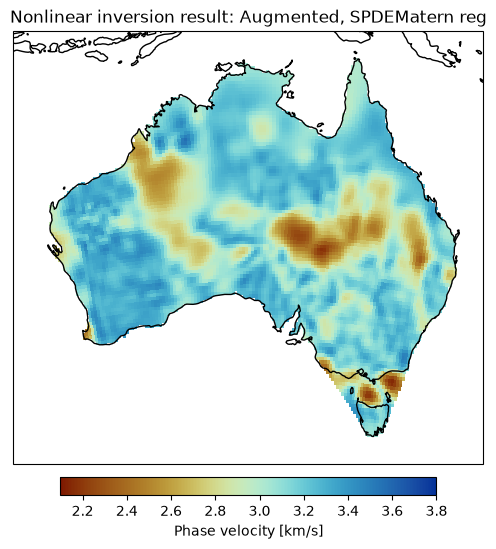

In [ ]:
if(use_gaussian_reg):
    ptitle2 = 'Nonlinear inversion result: Augmented, SPDEMatern reg'
else:
    ptitle2 = 'Nonlinear inversion result: Augmented, 2nd order Laplace reg'
fig_nonlin = plot_map(c_nonlin, title=ptitle2,
                      grid_shape=fm2d_grid_shape, extent=fm2d_extent, vmin=cmin, vmax=cmax)
save_fig(fig_nonlin, 'Nonlinear_LS_aug')
fig_nonlin

The nonlinear result shows similar structure to the linear case but with more detail at the fine scale.

The linear and nonlinear results seem consistent, but we have had to impose a particular choice of model parameterisation and also type of regularization, and weighting. To complete the research project we may want to drop some of these assumptions and also look at estimating uncertainty in the resulting slowness model.

## Trans-dimensional Bayesian Inversion

The deterministic inversions above produce a single "best" model, but they do not quantify **uncertainty**. How confident should one be in the velocity at a given point? Where does the data constrain the model well, and where is it poorly resolved?

**Trans-dimensional Bayesian inversion** addresses these questions by sampling the posterior probability distribution over models using reversible-jump Markov chain Monte Carlo (RJ-MCMC). Key features:

- **Variable complexity** — The number of Voronoi cells is itself a parameter, so the data determines the appropriate level of detail
- **No explicit regularisation** — Parsimony is enforced by the trans-dimensional prior (Occam's razor is built in)
- **Uncertainty quantification** — The ensemble of posterior samples provides mean, standard deviation, and full probability distributions
- **Noise estimation** — Data noise standard deviation is treated as an unknown and estimated jointly

The CoFI pattern remains the same: define a `BaseProblem`, set `InversionOptions` to use `"bayesbay"`, and call `Inversion.run()`. The existing Jacobian `A` and data vector `d_obs` are reused directly.

### Bayesian Formulation

In the Bayesian framework, the solution to the inverse problem is the **posterior probability distribution** over models, given by Bayes' theorem:

$$p(\mathbf{m} | \mathbf{d}) \propto p(\mathbf{d} | \mathbf{m}) \, p(\mathbf{m})$$

where $p(\mathbf{d} | \mathbf{m})$ is the likelihood function and $p(\mathbf{m})$ is the prior. Rather than seeking a single optimal model, this distribution is sampled to characterise the full range of models consistent with the data.

For Gaussian data noise with standard deviation $\sigma$, the log-likelihood is:

$$\log p(\mathbf{d} | \mathbf{m}) = -\frac{1}{2\sigma^2} \|\mathbf{d} - \mathbf{A}\mathbf{s}(\mathbf{m})\|^2 + \text{const}$$

where $\mathbf{s}(\mathbf{m}) = 1/\mathbf{v}$ is the slowness vector derived from the velocity model. The noise level $\sigma$ is itself treated as an unknown parameter with a uniform prior, estimated jointly with the model (hierarchical Bayes).

### Trans-dimensional Inference and Voronoi Tessellations

In fixed-dimensional inversion, the number of model parameters is prescribed. **Trans-dimensional** inversion allows the dimensionality itself — here, the number of Voronoi cells — to vary as a free parameter. The model space becomes a union over subspaces of different dimension:

$$\mathcal{M} = \bigcup_{k=k_{\min}}^{k_{\max}} \mathcal{M}_k$$

where $\mathcal{M}_k$ denotes the space of models with $k$ Voronoi cells. Each model consists of:
- $k$ nuclei positions $\{(\text{lon}_i, \text{lat}_i)\}_{i=1}^{k}$ within the Australian domain
- $k$ velocity values $\{v_i\}_{i=1}^{k}$, one per cell

The Voronoi tessellation partitions the domain such that each point is assigned to the nearest nucleus. This naturally produces an adaptive parameterisation — regions requiring more detail receive more cells.

### Reversible-Jump MCMC

Sampling across dimensions of varying size requires **reversible-jump MCMC** (Green, 1995). The Markov chain explores the posterior through four types of moves:

1. **Birth**: Add a new Voronoi cell (increase $k$ by 1)
2. **Death**: Remove an existing cell (decrease $k$ by 1)
3. **Value perturbation**: Change the velocity of an existing cell
4. **Position perturbation**: Move a nucleus to a new location

Birth and death proposals require careful acceptance probabilities that account for the change in dimensionality (the Jacobian of the dimension-matching transformation). The trans-dimensional prior naturally penalises unnecessary complexity — models with more cells than justified by the data will be rejected, implementing a form of automatic Occam's razor.

> Green, P. J. (1995). Reversible jump Markov chain Monte Carlo computation and Bayesian model determination. *Biometrika*, 82(4), 711–732.

In [ ]:
import bayesbay as bb

### Grid Points for Interpolation

The midpoint of each seislib grid cell is computed as `(lon, lat)`. During sampling, BayesBay's KD-tree maps Voronoi cell values onto these grid points via nearest-neighbour interpolation, enabling reuse of the existing Jacobian `A`.

In [ ]:
# Compute cell midpoints from seislib mesh
# mesh columns: [latmin, latmax, lonmin, lonmax]
_mesh = tomo.grid.mesh
grid_points = np.column_stack([
    (_mesh[:, 2] + _mesh[:, 3]) / 2,  # lon midpoints
    (_mesh[:, 0] + _mesh[:, 1]) / 2,  # lat midpoints
])
print(f"Grid points: {grid_points.shape[0]} cells")
print(f"  Lon range: [{grid_points[:, 0].min():.2f}, {grid_points[:, 0].max():.2f}]")
print(f"  Lat range: [{grid_points[:, 1].min():.2f}, {grid_points[:, 1].max():.2f}]")

Grid points: 19328 cells
  Lon range: [111.05, 156.05]
  Lat range: [-46.05, -7.95]


In [ ]:
# Fine display grid for Bayesian maps — 5× finer than forward model grid (display only)
_res = grid_resolution / 5  # 0.06°
_lons = np.arange(lonmin, lonmax + _res, _res)
_lats = np.arange(latmin, latmax + _res, _res)
grid_lon_fine, grid_lat_fine = np.meshgrid(_lons, _lats)
grid_points_fine = np.column_stack([grid_lon_fine.ravel(), grid_lat_fine.ravel()])
print(f"Fine display grid: {grid_points_fine.shape[0]:,} points at {_res:.2f}°")

Fine display grid: 481,572 points at 0.06°


### Parameterisation

The model is parameterised as a **Voronoi tessellation** over the Australian domain:

- Each Voronoi cell carries a phase velocity value drawn from a uniform prior $v \in [2, 4]$ km/s
- The number of cells varies between 100 and 1500, controlled by the trans-dimensional prior
- A KD-tree is computed at each step for fast nearest-neighbour interpolation onto the fixed grid

In [ ]:
# Define prior on phase velocity per Voronoi cell
_vel_prior = bb.prior.UniformPrior('vel', vmin=2, vmax=4, perturb_std=0.1)

# Define trans-dimensional Voronoi discretisation
voronoi = bb.discretization.Voronoi2D(
    name='voronoi',
    polygon=australia_polygon,
    perturb_std=1,
    n_dimensions_min=100,
    n_dimensions_max=1500,
    parameters=[_vel_prior],
    compute_kdtree=True,
)

parameterization = bb.parameterization.Parameterization(voronoi)
print(f"Parameterisation: Voronoi2D, {voronoi._n_dimensions_min}–{voronoi._n_dimensions_max} cells")
print(f"  Velocity prior: Uniform[2, 4] km/s")
print(f"  Trans-dimensional: {voronoi.trans_d}")

Parameterisation: Voronoi2D, 100–1500 cells
  Velocity prior: Uniform[2, 4] km/s
  Trans-dimensional: True


### Forward Function and Likelihood

The forward function reuses the existing Jacobian `A` and observed data `d_obs`:

1. Extract Voronoi cell velocities and the KD-tree from the current state
2. Interpolate velocities onto the fixed grid via nearest-neighbour lookup
3. Convert to slowness and compute predicted data: $\mathbf{d}_{\text{pred}} = \mathbf{A} \cdot (1/\mathbf{v})$

Since `A` contains fractional path lengths (rows sum to 1) and `d_obs` is in s/m, the data is converted to s/km so that the velocity prior in km/s gives consistent units: $1/v$ [km/s] $=$ slowness [s/km].

The data noise standard deviation is treated as unknown, sampled jointly with the model from a uniform prior.

In [ ]:
# Convert d_obs from s/m to s/km for consistency with velocity in km/s
d_obs_skm = d_obs * 1000

def _bb_forward(kdtree, vel):
    """Core forward: KD-tree interpolation + A @ slowness."""
    nearest = kdtree.query(grid_points)[1]
    interp_vel = vel[nearest]
    return interp_vel, A @ (1.0 / interp_vel)

def bb_forward(state):
    """BayesBay forward function wrapper."""
    _voronoi = state["voronoi"]
    kdtree = _voronoi.load_from_cache('kdtree')
    vel = _voronoi.get_param_values('vel')
    _, d_pred = _bb_forward(kdtree, vel)
    return d_pred

# Target: observed data with unknown noise
bb_target = bb.Target(
    'd_obs',
    d_obs_skm,
    std_min=0,
    std_max=0.01,
    std_perturb_std=0.001,
    noise_is_correlated=False,
)
bb_log_likelihood = bb.LogLikelihood(targets=bb_target, fwd_functions=bb_forward)

print(f"Forward function: A @ (1/interp_vel)")
print(f"  d_obs converted to s/km: [{d_obs_skm.min():.4f}, {d_obs_skm.max():.4f}]")
print(f"  Noise prior: Uniform[0, 0.01] s/km")

Forward function: A @ (1/interp_vel)
  d_obs converted to s/km: [0.2618, 0.4365]
  Noise prior: Uniform[0, 0.01] s/km


### MCMC Configuration

Configure the RJ-MCMC sampling parameters. For production runs, use more chains and iterations; for quick tests, reduce these values.

In [ ]:
bb_n_chains = mo.ui.slider(1, 24, value=presets['bb_n_chains'], step=1, label="Number of chains", show_value=True)
bb_n_iterations = mo.ui.slider(1000, 500_000, value=presets['bb_n_iterations'], step=1000, label="Total iterations", show_value=True)
bb_burnin = mo.ui.slider(0, 300_000, value=presets['bb_burnin'], step=1000, label="Burn-in iterations", show_value=True)
bb_save_every = mo.ui.slider(10, 500, value=presets['bb_save_every'], step=10, label="Save every N", show_value=True)
mo.vstack([
    mo.md("#### Sampling parameters"),
    bb_n_chains, bb_n_iterations, bb_burnin, bb_save_every,
])

Sampling parameters <marimo-slider data-initial-value='350000' data-label='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eTotal iterations\u003c/span\u003e\u003c/span\u003e"' data-start='1000' data-stop='500000' data-step='1000' data-steps='[]' data-debounce='false' data-disabled='false' data-orientation='"horizontal"' data-show-value='true' data-include-input='false' data-full-width='false'> <marimo-slider data-initial-value='150000' data-label='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eBurn-in iterations\u003c/span\u003e\u003c/span\u003e"' data-start='0' data-stop='300000' data-step='1000' data-steps='[]' data-debounce='false' data-disabled='false' data-orientation='"horizontal"' data-show-value='true' data-include-input='false' data-full-width='false'>

### Run the Inversion

The same `inv_problem` and `inv_options` are reconfigured once more — the `BaseProblem` → `InversionOptions` → `Inversion` pattern carries over from the deterministic sections. The forward function already reuses `A` and `d_obs` from earlier cells.

In [ ]:
# c_nonlin ensures DAG ordering: bayesbay runs after least_squares stage
_uses = c_nonlin
# Initialise chains from prior
starting_states = []
for _ in range(bb_n_chains.value):
    starting_states.append(parameterization.initialize())
    bb_log_likelihood.initialize(starting_states[-1])

# Reconfigure inv_options for bayesbay sampling
inv_options.set_solving_method("sampling")
inv_options.set_tool("bayesbay")
inv_options.hyper_params.clear()
inv_options.set_params(
    walkers_starting_states=starting_states,
    perturbation_funcs=parameterization.perturbation_funcs,
    log_like_ratio_func=bb_log_likelihood,
    n_chains=bb_n_chains.value,
    n_iterations=bb_n_iterations.value,
    burnin_iterations=bb_burnin.value,
    save_every=bb_save_every.value,
    verbose=False,
)

print(f"Running BayesBay trans-dimensional inversion...")
print(f"  Chains: {bb_n_chains.value}, Iterations: {bb_n_iterations.value:,}")
print(f"  Burn-in: {bb_burnin.value:,}, Save every: {bb_save_every.value}")
print("-" * 60)
transd_inv = Inversion(inv_problem, inv_options)
bb_results = transd_inv.run()
print("-" * 60)
print("Done.")

Running BayesBay trans-dimensional inversion...
  Chains: 12, Iterations: 350,000
  Burn-in: 150,000, Save every: 100
------------------------------------------------------------
------------------------------------------------------------
Done.


### Results

Extract posterior statistics from the saved MCMC samples: mean velocity, standard deviation (uncertainty), and estimated data noise.

In [ ]:
saved_states = bb_results.models

_std_noise = np.asarray(saved_states['d_obs.std'])
print(f"Posterior statistics from {len(saved_states['voronoi.vel'])} samples:")
print(f"  Noise std: [{_std_noise.min():.6f}, {_std_noise.max():.6f}] s/km")

Posterior statistics from 24000 samples:
  Noise std: [0.000280, 0.009678] s/km


The next cell projects each Voronoi slowness model from all chains of the MCMC onto a predefined `fine' grid so that a mean and standard deviation may be calculated. This can become a computationally intensive task and parallelization is used to make the calculation more efficient.

In [ ]:
from scipy.spatial import cKDTree as _cKDTree

_saved = bb_results.models
_nuclei_list = _saved["voronoi.discretization"]   # list of (n_k, 2) arrays — nuclei (lon, lat)
_vel_list    = _saved["voronoi.vel"]              # list of (n_k,) arrays — velocity per nucleus

_n = len(_nuclei_list)
_n_pts = len(grid_points_fine)

# Welford's online algorithm: accumulate mean and variance in O(n_grid) memory
# instead of materialising an (n_samples × n_grid) matrix (~92 GB for full run).
_count = 0
_mean  = np.zeros(_n_pts)
_M2    = np.zeros(_n_pts)
for _nuclei, _vel in zip(_nuclei_list, _vel_list):
    _kdt = _cKDTree(_nuclei)
    _x = _vel[_kdt.query(grid_points_fine, workers=-1)[1]]
    _count += 1
    _delta = _x - _mean
    _mean += _delta / _count
    _M2   += _delta * (_x - _mean)   # uses updated mean — Welford's trick

bb_statistics_fine = {
    "mean": _mean,
    "std":  np.sqrt(_M2 / _count),   # population std, matches np.std default (ddof=0)
}
print(f"Fine-grid statistics from {_n} samples, {len(grid_points_fine):,} points")
print(f"  Mean velocity: [{bb_statistics_fine['mean'].min():.3f}, {bb_statistics_fine['mean'].max():.3f}] km/s")
print(f"  Std deviation: [{bb_statistics_fine['std'].min():.4f}, {bb_statistics_fine['std'].max():.4f}] km/s")

Fine-grid statistics from 24000 samples, 481,572 points
  Mean velocity: [2.093, 3.778] km/s
  Std deviation: [0.0068, 0.7488] km/s


### Mean Velocity Map

The posterior mean phase velocity, obtained by averaging over all retained MCMC samples. This is directly comparable to the deterministic results above.

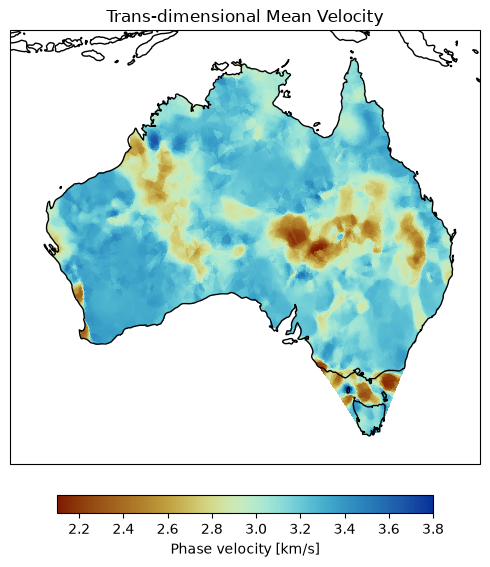

In [ ]:
fig_bb_mean = plot_map(
    bb_statistics_fine['mean'],
    title='Trans-dimensional Mean Velocity',
    lon_grid=grid_lon_fine, lat_grid=grid_lat_fine,
    vmin=cmin, vmax=cmax,
)
save_fig(fig_bb_mean, 'RJMCMC-mean')
fig_bb_mean

This mean model is comparable to that estimated by linear inversion above achieved with model estimation (although with no explicit regularization imposed). Here one can obsevere the influence of the underlying seislib grid used in the forward model.

### Uncertainty Map

The posterior standard deviation quantifies model uncertainty at each grid cell. Higher values indicate regions where the data provides less constraint — typically at domain edges or where ray coverage is sparse.

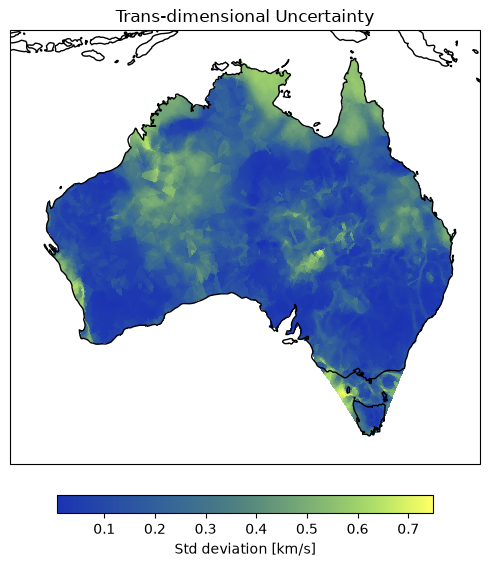

In [ ]:
fig_bb_std = plot_map(
    bb_statistics_fine['std'],
    title='Trans-dimensional Uncertainty',
    lon_grid=grid_lon_fine, lat_grid=grid_lat_fine,
    cmap=scm.imola,
    colorbar_label='Std deviation [km/s]',
)
save_fig(fig_bb_std, 'RJMCMC-uncertainty')
fig_bb_std

### Posterior Voronoi Samples

Six random draws from the posterior illustrate the diversity of models consistent with the data. Each sample has a different number and arrangement of Voronoi cells, reflecting the trans-dimensional nature of the inversion.

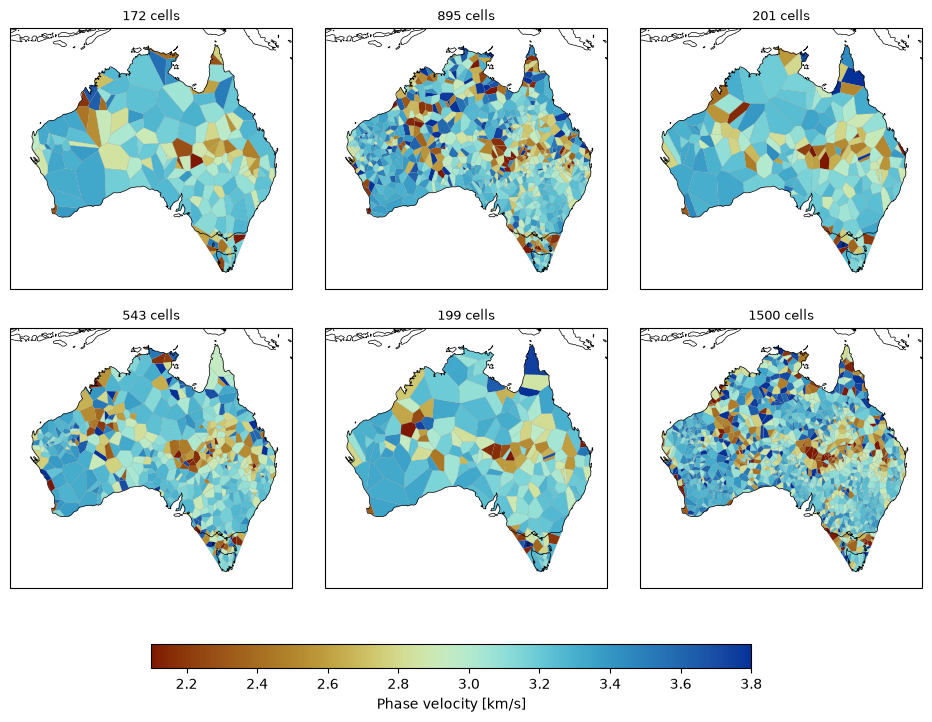

In [ ]:
_proj = ccrs.LambertConformal(
    central_longitude=135, central_latitude=-27,
    cutoff=80, standard_parallels=(-18, -36)
)
_transform = ccrs.PlateCarree()
_vmin = cmin
_vmax = cmax

_n_samples = len(saved_states['voronoi.vel'])
_rng = np.random.default_rng(42)
_indices = _rng.choice(_n_samples, size=min(6, _n_samples), replace=False)

fig_bb_samples, _axes = plt.subplots(
    2, 3, figsize=(12, 8),
    subplot_kw={'projection': _proj},
)
for _ax, _idx in zip(_axes.flat, _indices):
    _sites = saved_states['voronoi.discretization'][_idx]
    _vel = saved_states['voronoi.vel'][_idx]
    _n_cells = len(_vel)

    plot_tessellation(_sites, _vel, _ax, australia_polygon, scm.roma, _vmin, _vmax)
    _ax.coastlines(linewidth=0.5)
    _ax.set_extent([113, 153, -45, -8], crs=_transform)
    _ax.set_title(f'{_n_cells} cells', fontsize=9)

# Append shared colorbar
_sm = plt.cm.ScalarMappable(cmap=scm.roma, norm=plt.Normalize(vmin=_vmin, vmax=_vmax))
_sm.set_array([])
fig_bb_samples.subplots_adjust(bottom=0.18, wspace=0.05, hspace=0.15)
_cbar_ax = fig_bb_samples.add_axes([0.25, 0.08, 0.5, 0.03])
_cbar = fig_bb_samples.colorbar(_sm, cax=_cbar_ax, orientation='horizontal')
_cbar.set_label('Phase velocity [km/s]')

save_fig(fig_bb_samples, 'Voronoi cell_along chain')
fig_bb_samples

## Summary

This notebook demonstrated CoFI's capabilities for surface wave tomography:

**Linear inversion** (Great Circle Approximation):
- L-curve analysis for regularisation parameter selection
- Sparse matrix solvers (MINRES) for large-scale problems
- ~15,000 measurements and ~13,000 parameters

**Nonlinear inversion** (Ray Tracing with pyfm2d):
- Manual Gauss-Newton iteration with explicit control
- CoFI's built-in nonlinear solvers:
  - `scipy.optimize.minimize` (L-BFGS-B)
  - `scipy.optimize.least_squares` (trust-region-reflective)
- All approaches reuse the same `inv_problem` and `inv_options` objects

**Trans-dimensional Bayesian inversion** (BayesBay):
- Reversible-jump MCMC with variable Voronoi tessellation complexity
- Uncertainty quantification via posterior mean and standard deviation maps
- Joint estimation of data noise
- Same `A` matrix and `d_obs` — only the solver changes

### Key takeaways

- **Unified interface**: A single `inv_problem` and `inv_options` pair is reconfigured at each stage — linear, nonlinear, and Bayesian formulations all use the same `BaseProblem` → `InversionOptions` → `Inversion` workflow
- **Backend flexibility**: Switch solvers (MINRES, LSQR, trust-region, BayesBay) with parameter changes
- **Uncertainty quantification**: Trans-dimensional inversion provides principled uncertainty estimates without explicit regularisation
- **Extensibility**: Custom utilities like `LCurve` can wrap CoFI's building blocks
- **Research workflow**: Code developed for experimentation allows more considered choices to be made.

### Extensions

Possible extensions not covered here:
- **Cross-validation** for regularisation parameter selection
- **3D tomography** using the same CoFI patterns with volumetric forward operators

In [ ]:
# Clean up the worker module temp directory
import shutil

if scratch_dir.exists():
    shutil.rmtree(scratch_dir)

In [ ]:
import sys as _sys
import importlib.metadata as _importlib_metadata
from datetime import datetime as _datetime

# Packages explicitly imported in this notebook
_packages = [
    "h5py",
    "numpy",
    "scipy",
    "matplotlib",
    "cmcrameri",
    "cartopy",
    "seislib",
    "cofi",
    "marimo",
    "pyfm2d",
    "bayesbay",
    "shapely",
]

_env_info = [{"Package": "Python", "Version": _sys.version.split()[0]}]
for pkg in _packages:
    try:
        ver = _importlib_metadata.version(pkg)
        _env_info.append({"Package": pkg, "Version": ver})
    except _importlib_metadata.PackageNotFoundError:
        pass

mo.vstack([
    mo.md(f"**Environment** — {_datetime.now().strftime('%Y-%m-%d %H:%M')}"),
    mo.ui.table(_env_info, selection=None, page_size=len(_env_info))
])

Environment — 2026-07-21 10:01 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"Package\":\"Python\",\"Version\":\"3.12.3\"},{\"Package\":\"h5py\",\"Version\":\"3.16.0\"},{\"Package\":\"numpy\",\"Version\":\"2.5.1\"},{\"Package\":\"scipy\",\"Version\":\"1.18.0\"},{\"Package\":\"matplotlib\",\"Version\":\"3.11.1\"},{\"Package\":\"cmcrameri\",\"Version\":\"1.9\"},{\"Package\":\"cartopy\",\"Version\":\"0.25.0\"},{\"Package\":\"seislib\",\"Version\":\"1.2.1\"},{\"Package\":\"cofi\",\"Version\":\"0.2.12\"},{\"Package\":\"marimo\",\"Version\":\"0.23.14\"},{\"Package\":\"pyfm2d\",\"Version\":\"0.1.11\"},{\"Package\":\"bayesbay\",\"Version\":\"0.4.0\"},{\"Package\":\"shapely\",\"Version\":\"2.1.2\"}]"' data-total-rows='13' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='13' data-show-filters='false' data-show-download='true' data-show-search='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-hidden-columns='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>